In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import pandas as pd

In [5]:
def plot_first_timestep_nc(shape_path, base_dir, gauge_id, precip_file='prec_Meteoswiss.nc', temp_file='temp_Meteoswiss.nc', gauge_id_col='gauge_id', save_figs=True):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import os

    # Build file paths
    data_dir = f"{base_dir}/catchment_{gauge_id}/HBV/data_obs"
    precip_path = f"{data_dir}/{precip_file}"
    temp_path = f"{data_dir}/{temp_file}"

    # Load catchment shapefile
    catchments = gpd.read_file(shape_path)
    catchment = catchments.loc[catchments[gauge_id_col] == gauge_id]
    if len(catchment) == 0:
        print(f"No catchment found with gauge ID {gauge_id}")
        return None

    # Load NetCDF files
    precip_ds = xr.open_dataset(precip_path)
    temp_ds = xr.open_dataset(temp_path)

    # Use the correct variable names - RhiresD for precipitation
    precip_data = precip_ds['RhiresD'].isel(time=29)
    
    # For temperature, find the variable with time dimension
    temp_var = None
    for var in temp_ds.data_vars:
        if 'time' in temp_ds[var].dims:
            temp_var = var
            break
    
    if temp_var is None:
        print("No temperature variable with time dimension found!")
        return
    
    temp_data = temp_ds[temp_var].isel(time=29)

    # Get E/N coordinates
    x = precip_ds['E'].values
    y = precip_ds['N'].values

    # Create save directory if it doesn't exist
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Plot temperature
    # Plot temperature
    plt.figure(figsize=(10, 8))
    temp_plot = plt.pcolormesh(x, y, temp_data.values, cmap='RdBu_r', shading='auto')
    catchment.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=2)
    #plt.title('Temperature [°C]', fontsize=28, fontweight='bold')  # <-- Added title
    cbar_temp = plt.colorbar(temp_plot, shrink=0.7)
    cbar_temp.set_label('Temperature [°C]', fontsize=34, fontweight='bold')
    cbar_temp.set_ticks([])  # Remove all ticks
    cbar_temp.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks
    plt.axis('off')
    plt.tight_layout()
    
    if save_figs:
        plt.savefig(f'{save_dir}/temperature_catchment_{gauge_id}.png', 
                   bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

    # Plot precipitation
    plt.figure(figsize=(10, 8))
    precip_plot = plt.pcolormesh(x, y, precip_data.values, cmap='Blues', shading='auto')
    catchment.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=2)
    #plt.title('Precipitation [mm]', fontsize=28, fontweight='bold')  # <-- Added title
    cbar_precip = plt.colorbar(precip_plot, shrink=0.7)
    cbar_precip.set_label('Precipitation [mm]', fontsize=34, fontweight='bold')
    cbar_precip.set_ticks([])  # Remove all ticks
    cbar_precip.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks
    plt.axis('off')
    plt.tight_layout()
    
    #if save_figs:
    #    plt.savefig(f'{save_dir}/precipitation_catchment_{gauge_id}.png', 
    #               bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

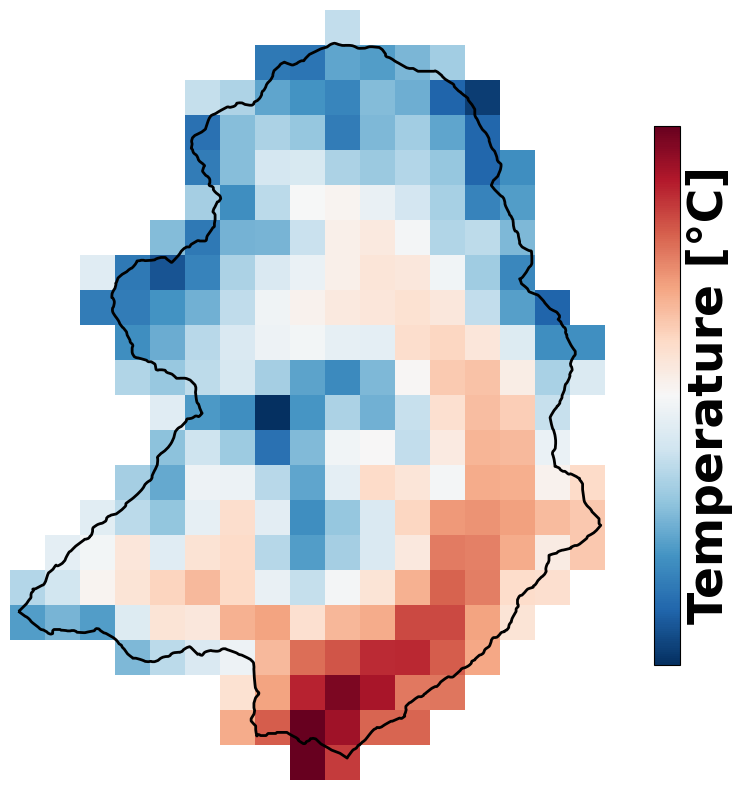

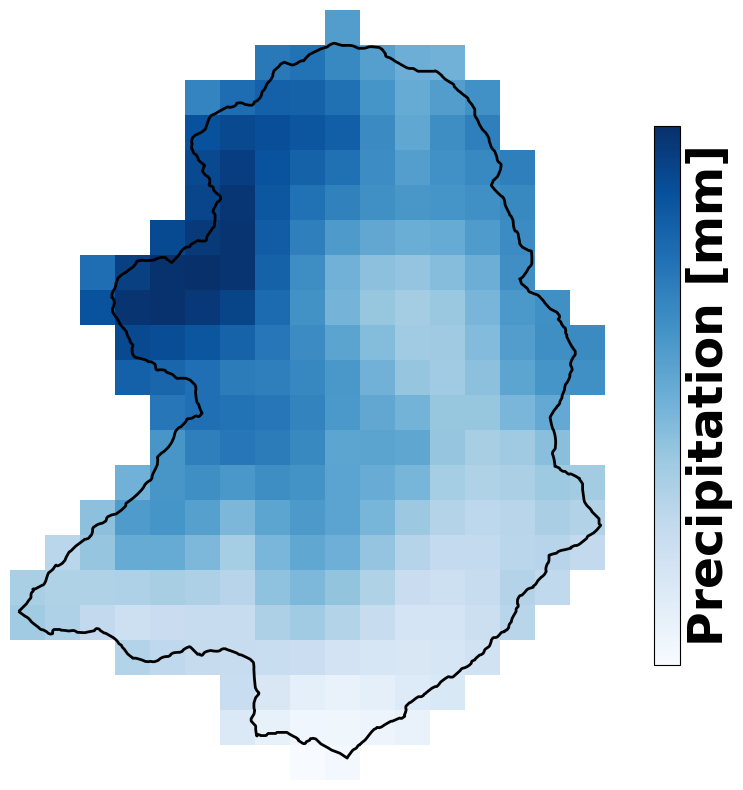

In [6]:
# Example usage:
shape_path = '/home/jberg/OneDrive/Raven_Switzerland/01_data/topo/CAMELS_CH_sub_catchments.shp'
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups'
gauge_id = 2161
plot_first_timestep_nc(shape_path, base_dir, gauge_id)

In [10]:
def plot_hru_precipitation_glacier_only(base_dir, gauge_id, time_step=150, save_figs=True):
    """Plot precipitation values for glacier HRUs only, with non-glacier HRUs shown in grey"""
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import xarray as xr
    import numpy as np
    import os

    # Build file paths
    data_dir = f"{base_dir}/catchment_{gauge_id}/HBV/data_obs"
    precip_path = f"{data_dir}/prec_Meteoswiss_new.nc"
    hru_path = f"{base_dir}/catchment_{gauge_id}/topo_files/HRU.shp"

    # Check if files exist
    if not os.path.exists(precip_path):
        print(f"NetCDF file not found at {precip_path}")
        return None

    if not os.path.exists(hru_path):
        print(f"HRU shapefile not found at {hru_path}")
        return None

    # Load NetCDF precipitation data
    try:
        precip_ds = xr.open_dataset(precip_path)
        print(f"NetCDF variables: {list(precip_ds.data_vars.keys())}")
        print(f"NetCDF dimensions: {list(precip_ds.dims.keys())}")

        # Get precipitation data for specified time step
        precip_data = precip_ds['data'].isel(time=time_step)
        print(f"Precipitation data shape: {precip_data.shape}")
        print(f"Precipitation range: {precip_data.min().values:.2f} to {precip_data.max().values:.2f}")

        # Extract values and ensure they're 1D
        if len(precip_data.shape) == 2:
            precip_values = precip_data.values.flatten()
        else:
            precip_values = precip_data.values

    except Exception as e:
        print(f"Error loading NetCDF data: {e}")
        return None

    # Load HRU shapefile
    try:
        hru_gdf = gpd.read_file(hru_path)
        print(f"Number of HRUs: {len(hru_gdf)}")
        print(f"HRU columns: {hru_gdf.columns.tolist()}")

        # CRITICAL FIX: Sort HRUs the same way as in the preprocessing script
        hru_id_col = 'HRU_ID' if 'HRU_ID' in hru_gdf.columns else 'HRU ID'
        hru_gdf_sorted = hru_gdf.sort_values(by=hru_id_col).reset_index(drop=True)

        print(f"HRU ID column used: {hru_id_col}")
        print(f"HRU ID range: {hru_gdf_sorted[hru_id_col].min()} to {hru_gdf_sorted[hru_id_col].max()}")

    except Exception as e:
        print(f"Error loading HRU shapefile: {e}")
        return None

    # Check if precipitation data matches number of HRUs
    if len(precip_values) != len(hru_gdf_sorted):
        print(f"Warning: Precipitation data length ({len(precip_values)}) doesn't match HRUs ({len(hru_gdf_sorted)})")
        # Take the minimum to avoid index errors
        n_features = min(len(precip_values), len(hru_gdf_sorted))
        precip_values_subset = precip_values[:n_features]
        hru_subset = hru_gdf_sorted.iloc[:n_features].copy()
    else:
        precip_values_subset = precip_values
        hru_subset = hru_gdf_sorted.copy()

    # Assign precipitation values
    hru_subset['precipitation'] = precip_values_subset

    # ✅ IDENTIFY GLACIER HRUs
    # Check for landuse column
    landuse_col = None
    for col in ['Landuse_Cl', 'LAND_USE_CLASS', 'landuse', 'LandUse']:
        if col in hru_subset.columns:
            landuse_col = col
            break
    
    if landuse_col is None:
        print("ERROR: No landuse column found in HRU shapefile!")
        print(f"Available columns: {hru_subset.columns.tolist()}")
        return None
    
    print(f"Using landuse column: '{landuse_col}'")
    print(f"Unique landuse values: {sorted(hru_subset[landuse_col].unique())}")
    
    # Define glacier classes (typically 7 = GLACIER, 8 = MASKED_GLACIER)
    glacier_classes = [7, 8]
    is_glacier = hru_subset[landuse_col].isin(glacier_classes)
    
    num_glacier = is_glacier.sum()
    num_non_glacier = (~is_glacier).sum()
    
    print(f"\nGlacier HRUs: {num_glacier}")
    print(f"Non-glacier HRUs: {num_non_glacier}")
    
    # ✅ CREATE DISPLAY VALUE: precipitation for glaciers, NaN for non-glaciers
    hru_subset['display_precip'] = np.where(is_glacier, hru_subset['precipitation'], np.nan)
    
    # Get precipitation range for colorbar (only from glacier HRUs)
    glacier_precip = hru_subset.loc[is_glacier, 'precipitation']
    vmin = glacier_precip.min()
    vmax = glacier_precip.max()
    
    print(f"\nGlacier precipitation range: {vmin:.2f} to {vmax:.2f} mm")
    
    # Create save directory
    save_dir = '/home/jberg/OneDrive/Paper_writing/Paper_1/Figures/methodology'
    os.makedirs(save_dir, exist_ok=True)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # ✅ PLOT NON-GLACIER HRUs IN GREY FIRST
    hru_subset[~is_glacier].plot(
        color='lightgrey',
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        zorder=1
    )
    
    # ✅ PLOT GLACIER HRUs WITH PRECIPITATION COLORS ON TOP
    hru_subset[is_glacier].plot(
        column='precipitation',
        cmap='Blues',
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        zorder=2
    )

    # Add colorbar (only for glacier precipitation values)
    sm = plt.cm.ScalarMappable(cmap='Blues',
                              norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label('Irrigation [mm]', fontsize=28, fontweight='bold', labelpad=20)
    cbar.set_ticks([])  # Remove all ticks
    cbar.ax.tick_params(labelsize=0, length=0)  # Remove tick labels and ticks

    # Customize plot
    ax.set_aspect('equal')
    ax.axis('off')

    plt.tight_layout()

    # Save figure if requested
    if save_figs:
        plt.savefig(f'{save_dir}/hru_precipitation_glacier_only_catchment_{gauge_id}_t{time_step}.png',
                   bbox_inches='tight', transparent=True, dpi=300)

    plt.show()

    # Print summary statistics
    print(f"\nPrecipitation statistics for time step {time_step}:")
    print(f"  GLACIER HRUs only:")
    print(f"    Min: {glacier_precip.min():.2f} mm")
    print(f"    Max: {glacier_precip.max():.2f} mm")
    print(f"    Mean: {glacier_precip.mean():.2f} mm")
    print(f"    Std: {glacier_precip.std():.2f} mm")
    print(f"\n  ALL HRUs (including non-glacier):")
    print(f"    Min: {hru_subset['precipitation'].min():.2f} mm")
    print(f"    Max: {hru_subset['precipitation'].max():.2f} mm")
    print(f"    Mean: {hru_subset['precipitation'].mean():.2f} mm")

    return hru_subset

NetCDF variables: ['data', 'elevation']
NetCDF dimensions: ['time', 'x', 'y']
Precipitation data shape: (140, 1)
Precipitation range: 0.00 to 35.81
Number of HRUs: 140
HRU columns: ['HRU_ID', 'Area_m2', 'Area_km2', 'Elev_Mean', 'Elev_Min', 'Elev_Max', 'Slope_deg', 'Aspect_deg', 'Landuse_Cl', 'Latitude', 'Longitude', 'Glacier_Cl', 'Aspect_Cl', 'geometry']
HRU ID column used: HRU_ID
HRU ID range: 1 to 140
Using landuse column: 'Landuse_Cl'
Unique landuse values: [np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(6.0), np.float64(8.0)]

Glacier HRUs: 70
Non-glacier HRUs: 70

Glacier precipitation range: 0.00 to 35.81 mm


/tmp/ipykernel_572329/2853611190.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"NetCDF dimensions: {list(precip_ds.dims.keys())}")


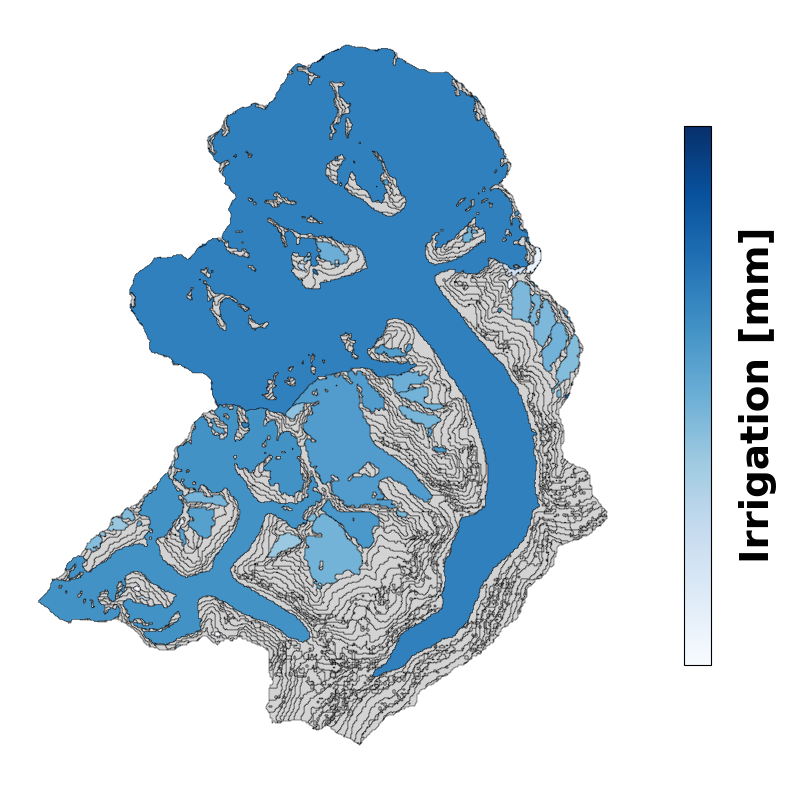


Precipitation statistics for time step 170:
  GLACIER HRUs only:
    Min: 0.00 mm
    Max: 35.81 mm
    Mean: 16.45 mm
    Std: 7.57 mm

  ALL HRUs (including non-glacier):
    Min: 0.00 mm
    Max: 35.81 mm
    Mean: 8.42 mm


In [11]:
base_dir = '/home/jberg/OneDrive/Raven_Switzerland/02_model_setups_coupled'
gauge_id = 2161
hru_precip_data = plot_hru_precipitation_glacier_only(base_dir, gauge_id, time_step=170)

In [31]:
def plot_snowmelt_regime_comparison(base_dir, config_dir, gauge_id, model_type='HBV', 
                                   validation_start=None, validation_end=None):
    """
    Compare two different snowmelt regimes:
    1. Snowmelt from mass loadings file (new method)
    2. Snowmelt from whole basin (SubBasin file)
    
    Parameters:
    -----------
    base_dir : str
        Base directory path (e.g., '/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109')
    config_dir : str
        Config directory name (e.g., '02_model_setups_coupled_sr')
    gauge_id : str or int
        Gauge ID (e.g., 2268)
    model_type : str
        Model type (default: 'HBV')
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    import geopandas as gpd
    import csv
    
    gauge_id = str(gauge_id)
    
    # Use default dates if not provided
    if validation_start is None:
        validation_start = '2010-01-01'
    if validation_end is None:
        validation_end = '2020-12-31'
    
    print(f"Comparing snowmelt regimes for catchment {gauge_id}:")
    print(f"  - Base directory: {base_dir}")
    print(f"  - Config directory: {config_dir}")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # ========================================
    # 1. LOAD CATCHMENT AREA FOR CONVERSION
    # ========================================
    
    config_path = Path(base_dir) / config_dir
    topo_dir = config_path / f"catchment_{gauge_id}" / "topo_files"
    catchment_shape_file = topo_dir / "HRU.shp"
    
    try:
        if catchment_shape_file.exists():
            hru_gdf = gpd.read_file(catchment_shape_file)
            total_area_km2 = hru_gdf['Area_km2'].sum()
            # Conversion factor: m³/s to mm/day
            conversion_m3s_to_mm_day = 86400 / (total_area_km2 * 1000000) * 1000
            print(f"  - Catchment area: {total_area_km2:.2f} km²")
            print(f"  - Conversion factor: {conversion_m3s_to_mm_day:.6f}")
        else:
            print(f"ERROR: Catchment shapefile not found: {catchment_shape_file}")
            return None
    except Exception as e:
        print(f"ERROR: Could not load catchment area: {e}")
        return None
    
    # ========================================
    # 2. LOAD SNOWMELT FROM MASS LOADINGS (NEW METHOD)
    # ========================================
    
    print("\n1. Loading snowmelt from mass loadings file (new method)...")
    
    model_dir = config_path / f"catchment_{gauge_id}" / model_type
    snowmelt_file = model_dir / "output" / f"{gauge_id}_{model_type}_SNOWMELTMassLoadings.csv"
    
    if not snowmelt_file.exists():
        print(f"ERROR: Snowmelt mass loadings file not found: {snowmelt_file}")
        return None
    
    try:
        # Read mass loadings file
        snowmelt_df1 = pd.read_csv(snowmelt_file)
        
        # Parse dates
        if 'date' not in snowmelt_df1.columns:
            print(f"ERROR: 'date' column not found in mass loadings file")
            return None
        snowmelt_df1['date'] = pd.to_datetime(snowmelt_df1['date'])
        
        # Find gauge column
        gauge_col = f"{gauge_id} m3/s"
        if gauge_col not in snowmelt_df1.columns:
            gauge_col = gauge_id
            if gauge_col not in snowmelt_df1.columns:
                print(f"ERROR: Column for gauge {gauge_id} not found")
                print(f"Available columns: {snowmelt_df1.columns.tolist()}")
                return None
        
        # Convert from m³/s to mm/day
        snowmelt_df1['snowmelt_m3s'] = snowmelt_df1[gauge_col]
        snowmelt_df1['snowmelt_mm_day'] = snowmelt_df1['snowmelt_m3s'] * conversion_m3s_to_mm_day
        
        # Filter for validation period
        start_date = pd.to_datetime(validation_start)
        end_date = pd.to_datetime(validation_end)
        
        mask1 = (snowmelt_df1['date'] >= start_date) & (snowmelt_df1['date'] <= end_date)
        snowmelt_df1 = snowmelt_df1[mask1].copy()
        
        if len(snowmelt_df1) == 0:
            print(f"ERROR: No data found for validation period")
            return None
        
        print(f"   ✓ Loaded {len(snowmelt_df1)} records")
        print(f"   - Mean: {snowmelt_df1['snowmelt_mm_day'].mean():.4f} mm/day")
        print(f"   - Max: {snowmelt_df1['snowmelt_mm_day'].max():.4f} mm/day")
        
    except Exception as e:
        print(f"ERROR: Failed to load mass loadings data: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # ========================================
    # 3. LOAD SNOWMELT FROM WHOLE BASIN (SUBBASIN METHOD)
    # ========================================
    
    print("\n2. Loading snowmelt from whole basin (SubBasin file)...")
    
    snowmelt_subbasin_file = model_dir / "output" / f"{gauge_id}_{model_type}_TO_LAKE_STORAGE_Daily_Average_BySubbasin.csv"
    
    if not snowmelt_subbasin_file.exists():
        print(f"ERROR: SubBasin file not found: {snowmelt_subbasin_file}")
        return None
    
    try:
        # ✅ READ FILE, SKIP SECOND ROW
        with open(snowmelt_subbasin_file, 'r') as f:
            reader = csv.reader(f)
            first_row = next(reader)  # Read first row (headers)
            next(reader)  # Skip second row
            
            # Read remaining data
            data_rows = list(reader)
        
        # Create DataFrame from data rows
        snowmelt_subbasin_df = pd.DataFrame(data_rows, columns=first_row)
        
        print(f"   - Read {len(snowmelt_subbasin_df)} rows from SubBasin file")
        print(f"   - Columns: {snowmelt_subbasin_df.columns.tolist()}")
        
        # ✅ PARSE DATES (from 'SubBasin:' column)
        if 'SubBasin:' in snowmelt_subbasin_df.columns:
            snowmelt_subbasin_df['date'] = pd.to_datetime(snowmelt_subbasin_df['SubBasin:'])
        else:
            print(f"ERROR: 'SubBasin:' column not found in SubBasin file")
            print(f"Available columns: {snowmelt_subbasin_df.columns.tolist()}")
            return None
        
        # ✅ GET DATA FROM COLUMN '1'
        if '1' not in snowmelt_subbasin_df.columns:
            print(f"ERROR: Column '1' not found in SubBasin file")
            print(f"Available columns: {snowmelt_subbasin_df.columns.tolist()}")
            return None
        
        # Convert to numeric and calculate daily rates from cumulative
        snowmelt_subbasin_df['snowmelt_cumulative'] = pd.to_numeric(snowmelt_subbasin_df['1'], errors='coerce')
        snowmelt_subbasin_df['snowmelt_mm_day'] = snowmelt_subbasin_df['snowmelt_cumulative'].diff().fillna(0)
        snowmelt_subbasin_df['snowmelt_mm_day'] = snowmelt_subbasin_df['snowmelt_mm_day'].clip(lower=0)
        
        # Filter by validation period (AFTER differencing!)
        mask2 = (snowmelt_subbasin_df['date'] >= start_date) & (snowmelt_subbasin_df['date'] <= end_date)
        snowmelt_subbasin_df = snowmelt_subbasin_df[mask2].copy()
        
        if len(snowmelt_subbasin_df) == 0:
            print(f"ERROR: No SubBasin data for validation period")
            return None
        
        print(f"   ✓ Loaded {len(snowmelt_subbasin_df)} records")
        print(f"   - Mean: {snowmelt_subbasin_df['snowmelt_mm_day'].mean():.4f} mm/day")
        print(f"   - Max: {snowmelt_subbasin_df['snowmelt_mm_day'].max():.4f} mm/day")
        
    except Exception as e:
        print(f"ERROR: Failed to load SubBasin data: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # ========================================
    # 4. CALCULATE MONTHLY REGIMES
    # ========================================
    
    print("\n3. Calculating monthly regimes...")
    
    # Method 1: Mass loadings
    snowmelt_df1['month'] = snowmelt_df1['date'].dt.month
    regime1 = snowmelt_df1.groupby('month')['snowmelt_mm_day'].mean()
    
    # Method 2: Whole basin (SubBasin)
    snowmelt_subbasin_df['month'] = snowmelt_subbasin_df['date'].dt.month
    regime2 = snowmelt_subbasin_df.groupby('month')['snowmelt_mm_day'].mean()
    
    # ========================================
    # 5. CREATE COMPARISON PLOT
    # ========================================
    
    print("\n4. Creating comparison plot...")
    
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot both regimes with nicer colors
    plt.plot(months, regime1.values, color='#246160', linewidth=4, marker='o', markersize=10,
            label='Snowmelt Contribution', zorder=3)
    
    plt.plot(months, regime2.values, color='#ef9b66', linewidth=3.5, marker='s', markersize=9,
            linestyle='--', label='Snowmelt', zorder=2)
    
    # Formatting with larger fonts
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Snowmelt (mm/day)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_dir = Path(base_dir) / config_dir / f"catchment_{gauge_id}" / model_type / "output" / "plots" / "contributions"
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f'snowmelt_regime_comparison_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved comparison plot to: {save_path}")
    plt.show()
    
    # ========================================
    # 6. PRINT SUMMARY
    # ========================================
    
    print(f"\nSnowmelt Regime Comparison Summary:")
    print(f"  Catchment: {gauge_id}")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"\n  Annual totals:")
    print(f"    Mass Loadings: {regime1.sum() * 30.44:.1f} mm/year")
    print(f"    Whole Basin: {regime2.sum() * 30.44:.1f} mm/year")
    print(f"\n  Peak month:")
    print(f"    Mass Loadings: {month_names[regime1.idxmax()-1]} ({regime1.max():.4f} mm/day)")
    print(f"    Whole Basin: {month_names[regime2.idxmax()-1]} ({regime2.max():.4f} mm/day)")
    
    return {
        'regime_mass_loadings': regime1,
        'regime_whole_basin': regime2
    }

Comparing snowmelt regimes for catchment 2268:
  - Base directory: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109
  - Config directory: 02_model_setups_coupled_sr
  - Period: 2010-01-01 to 2020-12-31
  - Catchment area: 39.25 km²
  - Conversion factor: 2.201149

1. Loading snowmelt from mass loadings file (new method)...
   ✓ Loaded 4018 records
   - Mean: 1.5285 mm/day
   - Max: 17.4440 mm/day

2. Loading snowmelt from whole basin (SubBasin file)...
   - Read 7670 rows from SubBasin file
   - Columns: ['', 'SubBasin:', '1', '']
   ✓ Loaded 4017 records
   - Mean: 1.6087 mm/day
   - Max: 20.5000 mm/day

3. Calculating monthly regimes...

4. Creating comparison plot...

✓ Saved comparison plot to: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/plots/contributions/snowmelt_regime_comparison_2268.png


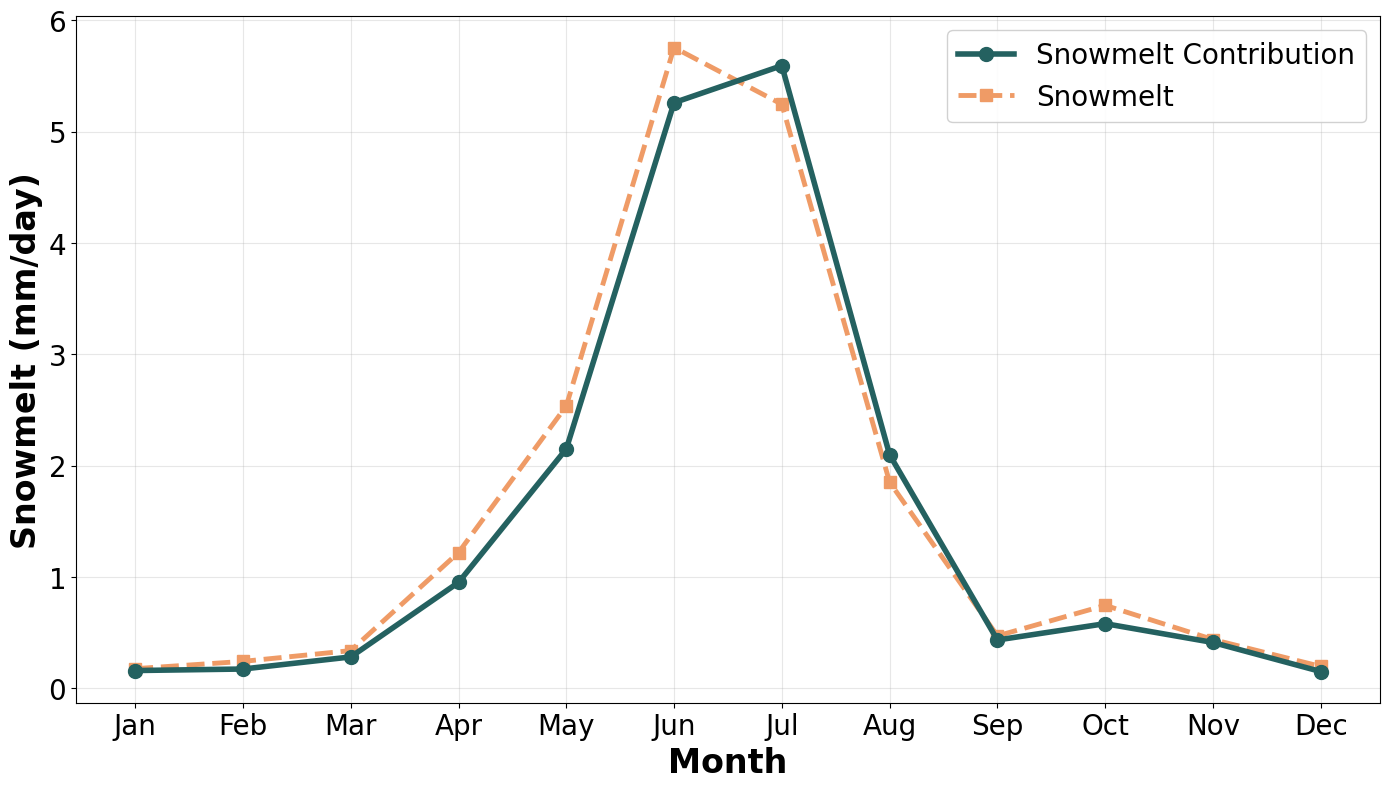


Snowmelt Regime Comparison Summary:
  Catchment: 2268
  Period: 2010-01-01 to 2020-12-31

  Annual totals:
    Mass Loadings: 555.6 mm/year
    Whole Basin: 585.3 mm/year

  Peak month:
    Mass Loadings: Jul (5.5938 mm/day)
    Whole Basin: Jun (5.7567 mm/day)


In [32]:
# Run the comparison
result = plot_snowmelt_regime_comparison(
    base_dir='/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109',
    config_dir='02_model_setups_coupled_sr',
    gauge_id=2268,
    model_type='HBV',
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [35]:
def plot_snowmelt_by_elevation_bands(base_dir, config_dir, gauge_id, model_type='HBV', 
                                     validation_start=None, validation_end=None):
    """
    Plot snowmelt regimes for all elevation bands with a color gradient.
    
    Parameters:
    -----------
    base_dir : str
        Base directory path
    config_dir : str
        Config directory name
    gauge_id : str or int
        Gauge ID
    model_type : str
        Model type (default: 'HBV')
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from pathlib import Path
    import geopandas as gpd
    import re
    
    gauge_id = str(gauge_id)
    
    # Use default dates if not provided
    if validation_start is None:
        validation_start = '2010-01-01'
    if validation_end is None:
        validation_end = '2020-12-31'
    
    print(f"Plotting snowmelt by elevation bands for catchment {gauge_id}:")
    print(f"  - Base directory: {base_dir}")
    print(f"  - Config directory: {config_dir}")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # ========================================
    # 1. LOAD CATCHMENT AREA FOR CONVERSION
    # ========================================
    
    config_path = Path(base_dir) / config_dir
    topo_dir = config_path / f"catchment_{gauge_id}" / "topo_files"
    catchment_shape_file = topo_dir / "HRU.shp"
    
    try:
        if catchment_shape_file.exists():
            hru_gdf = gpd.read_file(catchment_shape_file)
            total_area_km2 = hru_gdf['Area_km2'].sum()
            # Conversion factor: m³/s to mm/day
            conversion_m3s_to_mm_day = 86400 / (total_area_km2 * 1000000) * 1000
            print(f"  - Catchment area: {total_area_km2:.2f} km²")
            print(f"  - Conversion factor: {conversion_m3s_to_mm_day:.6f}")
        else:
            print(f"ERROR: Catchment shapefile not found: {catchment_shape_file}")
            return None
    except Exception as e:
        print(f"ERROR: Could not load catchment area: {e}")
        return None
    
    # ========================================
    # 2. FIND ALL ELEVATION BAND FILES
    # ========================================
    
    model_dir = config_path / f"catchment_{gauge_id}" / model_type
    output_dir = model_dir / "output"
    
    # Pattern to match elevation band files
    pattern = f"{gauge_id}_{model_type}_SNOWMELT*MassLoadings.csv"
    
    # Find all matching files
    elevation_files = sorted(output_dir.glob(pattern))
    
    if not elevation_files:
        print(f"ERROR: No elevation band files found matching pattern: {pattern}")
        return None
    
    print(f"\n1. Found {len(elevation_files)} elevation band files:")
    
    # ========================================
    # 3. EXTRACT ELEVATION RANGES AND SORT
    # ========================================
    
    elevation_data = []
    
    # Regex to extract elevation range (e.g., "1700-1800m")
    elevation_pattern = re.compile(r'SNOWMELT(\d+)-(\d+)m')
    
    for file_path in elevation_files:
        match = elevation_pattern.search(file_path.name)
        if match:
            lower_elev = int(match.group(1))
            upper_elev = int(match.group(2))
            elevation_data.append({
                'file': file_path,
                'lower': lower_elev,
                'upper': upper_elev,
                'mid': (lower_elev + upper_elev) / 2,
                'label': f"{lower_elev}-{upper_elev}m"
            })
    
    # Sort by lower elevation (lowest first)
    elevation_data.sort(key=lambda x: x['lower'])
    
    for ed in elevation_data:
        print(f"   - {ed['label']}: {ed['file'].name}")
    
    # ========================================
    # 4. LOAD DATA FROM EACH ELEVATION BAND
    # ========================================
    
    print("\n2. Loading data from elevation band files...")
    
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    regimes = {}
    
    for ed in elevation_data:
        try:
            # Read mass loadings file
            df = pd.read_csv(ed['file'])
            
            # Parse dates
            if 'date' not in df.columns:
                print(f"   WARNING: 'date' column not found in {ed['file'].name}, skipping")
                continue
            
            df['date'] = pd.to_datetime(df['date'])
            
            # Find gauge column
            gauge_col = f"{gauge_id} m3/s"
            if gauge_col not in df.columns:
                gauge_col = gauge_id
                if gauge_col not in df.columns:
                    # Try to find any column that looks like a data column
                    data_cols = [col for col in df.columns if col not in ['date', 'time', 'day']]
                    if data_cols:
                        gauge_col = data_cols[0]
                    else:
                        print(f"   WARNING: No data column found in {ed['file'].name}, skipping")
                        continue
            
            # Convert from m³/s to mm/day
            df['snowmelt_m3s'] = df[gauge_col]
            df['snowmelt_mm_day'] = df['snowmelt_m3s'] * conversion_m3s_to_mm_day
            
            # Filter for validation period
            mask = (df['date'] >= start_date) & (df['date'] <= end_date)
            df = df[mask].copy()
            
            if len(df) == 0:
                print(f"   WARNING: No data for validation period in {ed['file'].name}, skipping")
                continue
            
            # Calculate monthly regime
            df['month'] = df['date'].dt.month
            regime = df.groupby('month')['snowmelt_mm_day'].mean()
            
            regimes[ed['label']] = {
                'regime': regime,
                'mid_elevation': ed['mid'],
                'lower': ed['lower'],
                'upper': ed['upper']
            }
            
            print(f"   ✓ {ed['label']}: Mean = {regime.mean():.4f} mm/day, Max = {regime.max():.4f} mm/day")
            
        except Exception as e:
            print(f"   ERROR loading {ed['file'].name}: {e}")
            continue
    
    if not regimes:
        print("ERROR: No elevation band data could be loaded")
        return None
    
    # ========================================
    # 5. CREATE PLOT WITH COLOR GRADIENT
    # ========================================
    
    print("\n3. Creating elevation band regime plot...")
    
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Create color gradient from light blue (low elevation) to dark blue (high elevation)
    n_bands = len(regimes)
    colors = cm.Blues(np.linspace(0.3, 0.9, n_bands))
    
    # Sort regimes by elevation (low to high) for consistent color mapping
    sorted_regimes = sorted(regimes.items(), key=lambda x: x[1]['mid_elevation'])
    
    # Plot each elevation band
    for idx, (label, data) in enumerate(sorted_regimes):
        regime = data['regime']
        plt.plot(months, regime.values, 
                color=colors[idx], 
                linewidth=3, 
                marker='o', 
                markersize=7,
                label=label,
                alpha=0.8,
                zorder=3)
    
    # Formatting
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Snowmelt (mm/day)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    
    # Create legend with proper ordering (low to high elevation)
    plt.legend(fontsize=16, loc='best', framealpha=0.9, ncol=2)
    
    plt.tight_layout()
    
    # Save plot
    save_dir = Path(base_dir) / config_dir / f"catchment_{gauge_id}" / model_type / "output" / "plots" / "contributions"
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f'snowmelt_elevation_bands_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved elevation band plot to: {save_path}")
    plt.show()
    
    # ========================================
    # 6. PRINT SUMMARY
    # ========================================
    
    print(f"\nSnowmelt by Elevation Band Summary:")
    print(f"  Catchment: {gauge_id}")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"  Number of elevation bands: {len(regimes)}")
    print(f"\n  Peak snowmelt by elevation band:")
    
    for label, data in sorted_regimes:
        regime = data['regime']
        peak_month_idx = regime.idxmax()
        print(f"    {label}: {month_names[peak_month_idx-1]} ({regime.max():.4f} mm/day)")
    
    return regimes

Plotting snowmelt by elevation bands for catchment 2268:
  - Base directory: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109
  - Config directory: 02_model_setups_coupled_sr
  - Period: 2010-01-01 to 2020-12-31
  - Catchment area: 39.25 km²
  - Conversion factor: 2.201149

1. Found 20 elevation band files:
   - 1700-1800m: 2268_HBV_SNOWMELT1700-1800mMassLoadings.csv
   - 1800-1900m: 2268_HBV_SNOWMELT1800-1900mMassLoadings.csv
   - 1900-2000m: 2268_HBV_SNOWMELT1900-2000mMassLoadings.csv
   - 2000-2100m: 2268_HBV_SNOWMELT2000-2100mMassLoadings.csv
   - 2100-2200m: 2268_HBV_SNOWMELT2100-2200mMassLoadings.csv
   - 2200-2300m: 2268_HBV_SNOWMELT2200-2300mMassLoadings.csv
   - 2300-2400m: 2268_HBV_SNOWMELT2300-2400mMassLoadings.csv
   - 2400-2500m: 2268_HBV_SNOWMELT2400-2500mMassLoadings.csv
   - 2500-2600m: 2268_HBV_SNOWMELT2500-2600mMassLoadings.csv
   - 2600-2700m: 2268_HBV_SNOWMELT2600-2700mMassLoadings.csv
   - 2700-2800m: 2268_HBV_SNOWMELT2700-2800mMassLoadin

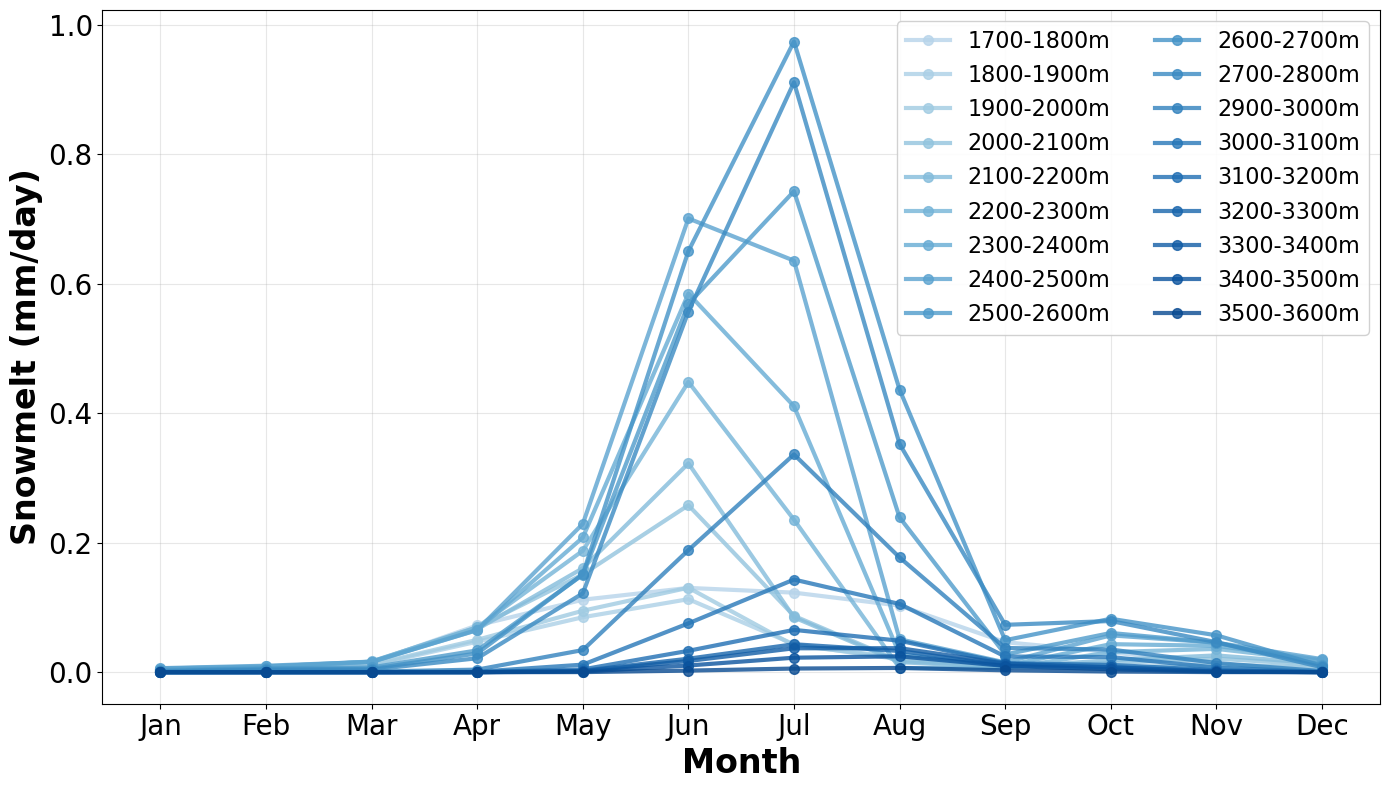


Snowmelt by Elevation Band Summary:
  Catchment: 2268
  Period: 2010-01-01 to 2020-12-31
  Number of elevation bands: 18

  Peak snowmelt by elevation band:
    1700-1800m: Jun (0.1302 mm/day)
    1800-1900m: Jun (0.1128 mm/day)
    1900-2000m: Jun (0.1304 mm/day)
    2000-2100m: Jun (0.2579 mm/day)
    2100-2200m: Jun (0.3225 mm/day)
    2200-2300m: Jun (0.4483 mm/day)
    2300-2400m: Jun (0.5848 mm/day)
    2400-2500m: Jun (0.7008 mm/day)
    2500-2600m: Jul (0.7429 mm/day)
    2600-2700m: Jul (0.9741 mm/day)
    2700-2800m: Jul (0.9111 mm/day)
    2900-3000m: Jul (0.3363 mm/day)
    3000-3100m: Jul (0.1431 mm/day)
    3100-3200m: Jul (0.0654 mm/day)
    3200-3300m: Jul (0.0432 mm/day)
    3300-3400m: Aug (0.0371 mm/day)
    3400-3500m: Aug (0.0245 mm/day)
    3500-3600m: Aug (0.0066 mm/day)


In [36]:
# Run the elevation band analysis
regimes = plot_snowmelt_by_elevation_bands(
    base_dir='/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109',
    config_dir='02_model_setups_coupled_sr',
    gauge_id=2268,
    model_type='HBV',
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [4]:
def plot_snowmelt_by_elevation_bands_stacked(base_dir, config_dir, gauge_id, model_type='HBV', 
                                             validation_start=None, validation_end=None):
    """
    Plot snowmelt regimes for all elevation bands as a stacked area chart.
    
    Parameters:
    -----------
    base_dir : str
        Base directory path
    config_dir : str
        Config directory name
    gauge_id : str or int
        Gauge ID
    model_type : str
        Model type (default: 'HBV')
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from pathlib import Path
    import geopandas as gpd
    import re
    
    gauge_id = str(gauge_id)
    
    # Use default dates if not provided
    if validation_start is None:
        validation_start = '2010-01-01'
    if validation_end is None:
        validation_end = '2020-12-31'
    
    print(f"Plotting snowmelt by elevation bands (stacked) for catchment {gauge_id}:")
    print(f"  - Base directory: {base_dir}")
    print(f"  - Config directory: {config_dir}")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # ========================================
    # 1. LOAD CATCHMENT AREA FOR CONVERSION
    # ========================================
    
    config_path = Path(base_dir) / config_dir
    topo_dir = config_path / f"catchment_{gauge_id}" / "topo_files"
    catchment_shape_file = topo_dir / "HRU.shp"
    
    try:
        if catchment_shape_file.exists():
            hru_gdf = gpd.read_file(catchment_shape_file)
            total_area_km2 = hru_gdf['Area_km2'].sum()
            # Conversion factor: m³/s to mm/day
            conversion_m3s_to_mm_day = 86400 / (total_area_km2 * 1000000) * 1000
            print(f"  - Catchment area: {total_area_km2:.2f} km²")
            print(f"  - Conversion factor: {conversion_m3s_to_mm_day:.6f}")
        else:
            print(f"ERROR: Catchment shapefile not found: {catchment_shape_file}")
            return None
    except Exception as e:
        print(f"ERROR: Could not load catchment area: {e}")
        return None
    
    # ========================================
    # 2. FIND ALL ELEVATION BAND FILES
    # ========================================
    
    model_dir = config_path / f"catchment_{gauge_id}" / model_type
    output_dir = model_dir / "output"
    
    # Pattern to match elevation band files
    pattern = f"{gauge_id}_{model_type}_SNOWMELT*MassLoadings.csv"
    
    # Find all matching files
    elevation_files = sorted(output_dir.glob(pattern))
    
    if not elevation_files:
        print(f"ERROR: No elevation band files found matching pattern: {pattern}")
        return None
    
    print(f"\n1. Found {len(elevation_files)} elevation band files:")
    
    # ========================================
    # 3. EXTRACT ELEVATION RANGES AND SORT
    # ========================================
    
    elevation_data = []
    
    # Regex to extract elevation range (e.g., "1700-1800m")
    elevation_pattern = re.compile(r'SNOWMELT(\d+)-(\d+)m')
    
    for file_path in elevation_files:
        match = elevation_pattern.search(file_path.name)
        if match:
            lower_elev = int(match.group(1))
            upper_elev = int(match.group(2))
            elevation_data.append({
                'file': file_path,
                'lower': lower_elev,
                'upper': upper_elev,
                'mid': (lower_elev + upper_elev) / 2,
                'label': f"{lower_elev}-{upper_elev}m"
            })
    
    # Sort by lower elevation (lowest first)
    elevation_data.sort(key=lambda x: x['lower'])
    
    for ed in elevation_data:
        print(f"   - {ed['label']}: {ed['file'].name}")
    
    # ========================================
    # 4. LOAD DATA FROM EACH ELEVATION BAND
    # ========================================
    
    print("\n2. Loading data from elevation band files...")
    
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    regimes = {}
    
    for ed in elevation_data:
        try:
            # Read mass loadings file
            df = pd.read_csv(ed['file'])
            
            # Parse dates
            if 'date' not in df.columns:
                print(f"   WARNING: 'date' column not found in {ed['file'].name}, skipping")
                continue
            
            df['date'] = pd.to_datetime(df['date'])
            
            # Find gauge column
            gauge_col = f"{gauge_id} m3/s"
            if gauge_col not in df.columns:
                gauge_col = gauge_id
                if gauge_col not in df.columns:
                    # Try to find any column that looks like a data column
                    data_cols = [col for col in df.columns if col not in ['date', 'time', 'day']]
                    if data_cols:
                        gauge_col = data_cols[0]
                    else:
                        print(f"   WARNING: No data column found in {ed['file'].name}, skipping")
                        continue
            
            # Convert from m³/s to mm/day
            df['snowmelt_m3s'] = df[gauge_col]
            df['snowmelt_mm_day'] = df['snowmelt_m3s'] * conversion_m3s_to_mm_day
            
            # Filter for validation period
            mask = (df['date'] >= start_date) & (df['date'] <= end_date)
            df = df[mask].copy()
            
            if len(df) == 0:
                print(f"   WARNING: No data for validation period in {ed['file'].name}, skipping")
                continue
            
            # Calculate monthly regime
            df['month'] = df['date'].dt.month
            regime = df.groupby('month')['snowmelt_mm_day'].mean()
            
            regimes[ed['label']] = {
                'regime': regime,
                'mid_elevation': ed['mid'],
                'lower': ed['lower'],
                'upper': ed['upper']
            }
            
            print(f"   ✓ {ed['label']}: Mean = {regime.mean():.4f} mm/day, Max = {regime.max():.4f} mm/day")
            
        except Exception as e:
            print(f"   ERROR loading {ed['file'].name}: {e}")
            continue
    
    if not regimes:
        print("ERROR: No elevation band data could be loaded")
        return None
    
    # ========================================
    # 5. CREATE STACKED AREA PLOT
    # ========================================
    
    print("\n3. Creating stacked area plot...")
    
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Sort regimes by elevation (low to high)
    sorted_regimes = sorted(regimes.items(), key=lambda x: x[1]['mid_elevation'])
    
    # Prepare data for stacking
    n_bands = len(sorted_regimes)
    data_matrix = np.zeros((12, n_bands))
    labels = []
    
    for idx, (label, data) in enumerate(sorted_regimes):
        regime = data['regime']
        data_matrix[:, idx] = regime.values
        labels.append(label)
    
    # Create color gradient from light blue (low elevation) to dark blue (high elevation)
    colors = cm.Blues(np.linspace(0.3, 0.9, n_bands))
    
    # Create stacked area plot
    ax = plt.gca()
    ax.stackplot(months, data_matrix.T, labels=labels, colors=colors, alpha=0.8)
    
    # Formatting
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Snowmelt (mm/day)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    
    # Create legend (reverse order so highest elevation is on top)
    handles, labels_plot = ax.get_legend_handles_labels()
    plt.legend(handles[::-1], labels_plot[::-1], fontsize=16, loc='best', framealpha=0.9, ncol=2)
    
    plt.tight_layout()
    
    # Save plot
    save_dir = Path(base_dir) / config_dir / f"catchment_{gauge_id}" / model_type / "output" / "plots" / "contributions"
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f'snowmelt_elevation_bands_stacked_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved stacked area plot to: {save_path}")
    plt.show()
    
    # ========================================
    # 6. PRINT SUMMARY
    # ========================================
    
    print(f"\nSnowmelt by Elevation Band Summary (Stacked):")
    print(f"  Catchment: {gauge_id}")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"  Number of elevation bands: {len(regimes)}")
    
    # Calculate total snowmelt per month
    total_regime = data_matrix.sum(axis=1)
    print(f"\n  Total snowmelt regime:")
    print(f"    Mean: {total_regime.mean():.4f} mm/day")
    print(f"    Max: {total_regime.max():.4f} mm/day (Month {np.argmax(total_regime) + 1})")
    
    print(f"\n  Contribution by elevation band (annual average %):")
    annual_totals = data_matrix.sum(axis=0)
    total_annual = annual_totals.sum()
    
    for idx, (label, data) in enumerate(sorted_regimes):
        contribution_pct = (annual_totals[idx] / total_annual) * 100
        print(f"    {label}: {contribution_pct:.1f}%")
    
    return regimes

Plotting snowmelt by elevation bands (stacked) for catchment 2268:
  - Base directory: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109
  - Config directory: 02_model_setups_coupled_sr
  - Period: 2010-01-01 to 2020-12-31
  - Catchment area: 39.25 km²
  - Conversion factor: 2.201149

1. Found 20 elevation band files:
   - 1700-1800m: 2268_HBV_SNOWMELT1700-1800mMassLoadings.csv
   - 1800-1900m: 2268_HBV_SNOWMELT1800-1900mMassLoadings.csv
   - 1900-2000m: 2268_HBV_SNOWMELT1900-2000mMassLoadings.csv
   - 2000-2100m: 2268_HBV_SNOWMELT2000-2100mMassLoadings.csv
   - 2100-2200m: 2268_HBV_SNOWMELT2100-2200mMassLoadings.csv
   - 2200-2300m: 2268_HBV_SNOWMELT2200-2300mMassLoadings.csv
   - 2300-2400m: 2268_HBV_SNOWMELT2300-2400mMassLoadings.csv
   - 2400-2500m: 2268_HBV_SNOWMELT2400-2500mMassLoadings.csv
   - 2500-2600m: 2268_HBV_SNOWMELT2500-2600mMassLoadings.csv
   - 2600-2700m: 2268_HBV_SNOWMELT2600-2700mMassLoadings.csv
   - 2700-2800m: 2268_HBV_SNOWMELT2700-2800m

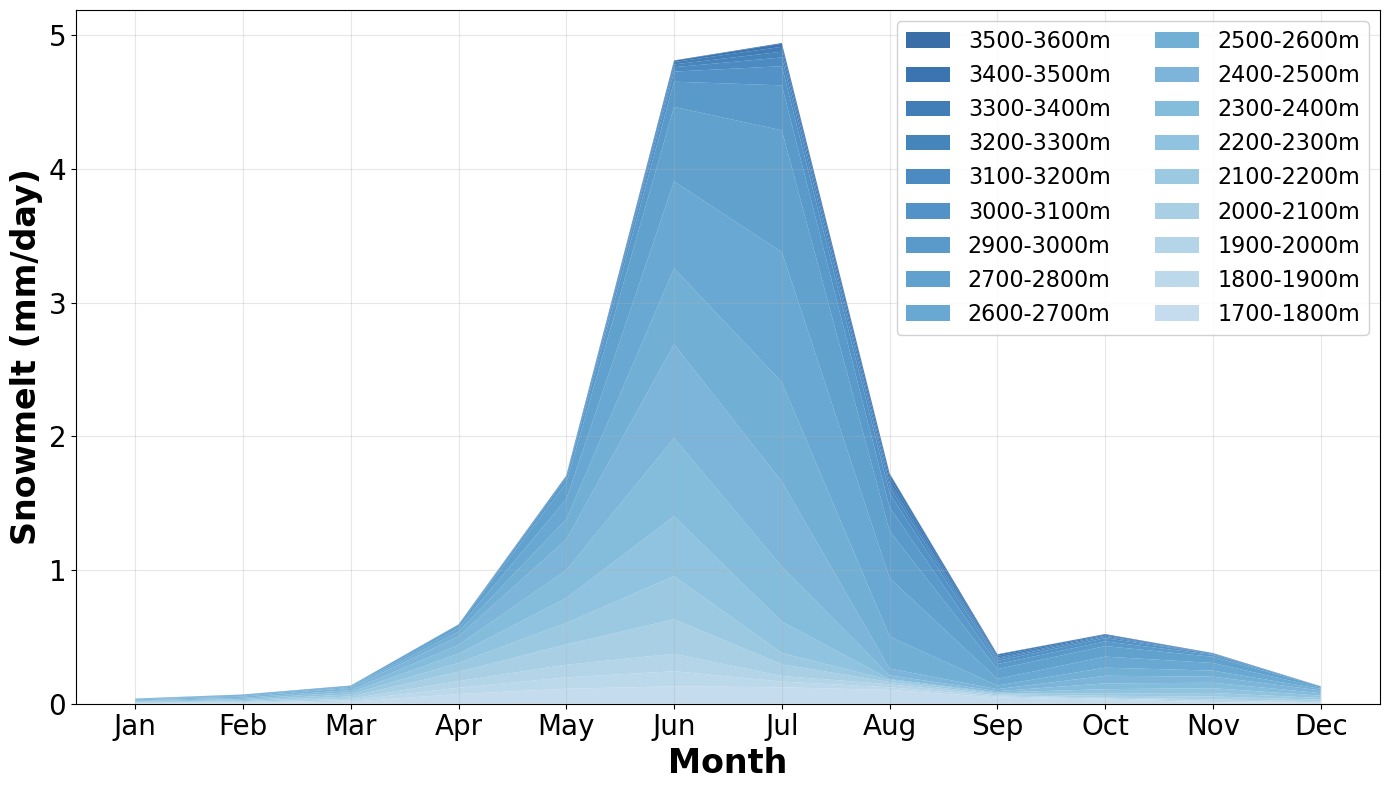


Snowmelt by Elevation Band Summary (Stacked):
  Catchment: 2268
  Period: 2010-01-01 to 2020-12-31
  Number of elevation bands: 18

  Total snowmelt regime:
    Mean: 1.2852 mm/day
    Max: 4.9417 mm/day (Month 7)

  Contribution by elevation band (annual average %):
    1700-1800m: 4.3%
    1800-1900m: 2.3%
    1900-2000m: 2.5%
    2000-2100m: 4.3%
    2100-2200m: 4.8%
    2200-2300m: 6.9%
    2300-2400m: 9.3%
    2400-2500m: 12.0%
    2500-2600m: 12.3%
    2600-2700m: 15.9%
    2700-2800m: 14.1%
    2900-3000m: 5.4%
    3000-3100m: 2.5%
    3100-3200m: 1.2%
    3200-3300m: 0.8%
    3300-3400m: 0.7%
    3400-3500m: 0.5%
    3500-3600m: 0.1%


In [5]:
# Run the stacked elevation band analysis
regimes = plot_snowmelt_by_elevation_bands_stacked(
    base_dir='/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109',
    config_dir='02_model_setups_coupled_sr',
    gauge_id=2268,
    model_type='HBV',
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [15]:
# First, import the necessary functions from postprocessing_single.py
import sys
sys.path.append('/home/jberg/Raven-world/src')

from postprocessing_single import (
    load_hydrograph_data,
    load_snowmelt_mass_loadings,
    load_glacier_melt_mass_loadings,
    setup_output_directories
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define the two plotting functions
def plot_streamflow_with_all_glacier_snowmelt_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot streamflow regime with total glacier melt and snowmelt contributions.
    Shows: Simulated streamflow, Observed streamflow, Snowmelt, and Total Glacier Melt (ALL)
    """
    
    gauge_id = config['gauge_id']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Creating streamflow regime with all glacier melt and snowmelt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load streamflow data
    streamflow_data = load_hydrograph_data(config)
    if streamflow_data is None:
        print("ERROR: Could not load streamflow data")
        return None
    
    # Filter for validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    streamflow_mask = (streamflow_data['date'] >= start_date) & (streamflow_data['date'] <= end_date)
    streamflow_filtered = streamflow_data[streamflow_mask].copy()
    
    if len(streamflow_filtered) == 0:
        print(f"ERROR: No streamflow data found for period {validation_start} to {validation_end}")
        return None
    
    # Calculate monthly regime for streamflow
    streamflow_filtered['month'] = streamflow_filtered['date'].dt.month
    
    streamflow_regime = {}
    if 'obs_Q' in streamflow_filtered.columns:
        streamflow_regime['observed'] = streamflow_filtered.groupby('month')['obs_Q'].mean()
    if 'sim_Q' in streamflow_filtered.columns:
        streamflow_regime['simulated'] = streamflow_filtered.groupby('month')['sim_Q'].mean()
    
    # 2. Load snowmelt data
    snowmelt_df = load_snowmelt_mass_loadings(config, validation_start, validation_end)
    if snowmelt_df is None:
        print("ERROR: Could not load snowmelt data")
        return None
    
    # Calculate monthly regime for snowmelt
    snowmelt_df['month'] = snowmelt_df['date'].dt.month
    snowmelt_regime = snowmelt_df.groupby('month')['snowmelt_m3s'].mean()
    
    # 3. Load glacier melt data (ALL)
    glacier_data = load_glacier_melt_mass_loadings(config, validation_start, validation_end)
    if glacier_data is None or glacier_data.get('all') is None:
        print("ERROR: Could not load ALL glacier melt data")
        return None
    
    # Calculate monthly regime for ALL glacier melt
    glacier_all_df = glacier_data['all']
    glacier_all_df['month'] = glacier_all_df['date'].dt.month
    glacier_all_regime = glacier_all_df.groupby('month')['glacier_melt_m3s'].mean()
    
    # 4. Create plot
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot filled polygons STACKED (bottom to top)
    # First: Plot glacier melt as filled polygon - light grey (BOTTOM)
    plt.fill_between(months, 0, glacier_all_regime.values, 
                     color='#D3D3D3', alpha=0.9, label='Glacier Runoff', zorder=1, 
                     edgecolor='#808080', linewidth=2)
    
    # Second: Plot snowmelt STACKED on top of glacier melt - light blue (TOP)
    plt.fill_between(months, glacier_all_regime.values, 
                     glacier_all_regime.values + snowmelt_regime.values, 
                     color='#B3D9FF', alpha=0.8, label='Snowmelt', zorder=2, 
                     edgecolor='#4DA6FF', linewidth=2)
    
    # Plot observed streamflow (line without markers)
    if 'observed' in streamflow_regime:
        plt.plot(months, streamflow_regime['observed'].values, 'k-', 
                linewidth=4, label='Observed Streamflow', zorder=4)
    
    # Plot simulated streamflow (dashed line without markers)
    if 'simulated' in streamflow_regime:
        plt.plot(months, streamflow_regime['simulated'].values, 'C0--', 
                linewidth=3.5, label='Simulated Streamflow', zorder=3)
    
    # Formatting with larger fonts
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Discharge (m³/s)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'streamflow_all_glacier_snowmelt_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved streamflow regime with all glacier melt plot to: {save_path}")
    plt.show()
    
    # Return all data
    return {
        'streamflow': streamflow_regime,
        'snowmelt': snowmelt_regime,
        'glacier_all': glacier_all_regime
    }


def plot_streamflow_with_separated_glacier_snowmelt_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot streamflow regime with separated glacier melt (SMALL, LARGE) and snowmelt contributions.
    """
    
    gauge_id = config['gauge_id']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Creating streamflow regime with separated glacier melt and snowmelt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load streamflow data
    streamflow_data = load_hydrograph_data(config)
    if streamflow_data is None:
        print("ERROR: Could not load streamflow data")
        return None
    
    # Filter for validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    streamflow_mask = (streamflow_data['date'] >= start_date) & (streamflow_data['date'] <= end_date)
    streamflow_filtered = streamflow_data[streamflow_mask].copy()
    
    if len(streamflow_filtered) == 0:
        print(f"ERROR: No streamflow data found for period {validation_start} to {validation_end}")
        return None
    
    # Calculate monthly regime for streamflow
    streamflow_filtered['month'] = streamflow_filtered['date'].dt.month
    
    streamflow_regime = {}
    if 'obs_Q' in streamflow_filtered.columns:
        streamflow_regime['observed'] = streamflow_filtered.groupby('month')['obs_Q'].mean()
    if 'sim_Q' in streamflow_filtered.columns:
        streamflow_regime['simulated'] = streamflow_filtered.groupby('month')['sim_Q'].mean()
    
    # 2. Load snowmelt data
    snowmelt_df = load_snowmelt_mass_loadings(config, validation_start, validation_end)
    if snowmelt_df is None:
        print("ERROR: Could not load snowmelt data")
        return None
    
    # Calculate monthly regime for snowmelt
    snowmelt_df['month'] = snowmelt_df['date'].dt.month
    snowmelt_regime = snowmelt_df.groupby('month')['snowmelt_m3s'].mean()
    
    # 3. Load glacier melt data (SMALL and LARGE)
    glacier_data = load_glacier_melt_mass_loadings(config, validation_start, validation_end)
    if glacier_data is None:
        print("ERROR: Could not load glacier melt data")
        return None
    
    # Calculate monthly regimes for SMALL and LARGE glacier melt
    glacier_regimes = {}
    
    if glacier_data.get('small') is not None:
        glacier_small_df = glacier_data['small']
        glacier_small_df['month'] = glacier_small_df['date'].dt.month
        glacier_regimes['small'] = glacier_small_df.groupby('month')['glacier_melt_m3s'].mean()
    else:
        print("WARNING: SMALL glacier data not available")
    
    if glacier_data.get('large') is not None:
        glacier_large_df = glacier_data['large']
        glacier_large_df['month'] = glacier_large_df['date'].dt.month
        glacier_regimes['large'] = glacier_large_df.groupby('month')['glacier_melt_m3s'].mean()
    else:
        print("WARNING: LARGE glacier data not available")
    
    if len(glacier_regimes) == 0:
        print("ERROR: No glacier melt data available")
        return None
    
    # 4. Create plot
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot filled polygons STACKED (bottom to top)
    # Layer 1 (BOTTOM): Large glacier melt - light grey
    if 'large' in glacier_regimes:
        plt.fill_between(months, 0, glacier_regimes['large'].values, 
                        color='#D3D3D3', alpha=0.9, label='Large Glacier Runoff', zorder=1,
                        edgecolor='#808080', linewidth=2)
        cumulative = glacier_regimes['large'].values.copy()
    else:
        cumulative = np.zeros(12)
    
    # Layer 2 (MIDDLE): Small glacier melt STACKED on top of large - darker grey
    if 'small' in glacier_regimes:
        plt.fill_between(months, cumulative, 
                        cumulative + glacier_regimes['small'].values, 
                        color='#A9A9A9', alpha=0.9, label='Small Glacier Runoff', zorder=2, 
                        edgecolor='#696969', linewidth=2)
        cumulative = cumulative + glacier_regimes['small'].values
    
    # Layer 3 (TOP): Snowmelt STACKED on top of all glacier melt - light blue
    plt.fill_between(months, cumulative, 
                     cumulative + snowmelt_regime.values, 
                     color='#B3D9FF', alpha=0.8, label='Snowmelt', zorder=3, 
                     edgecolor='#4DA6FF', linewidth=2)
    
    # Plot observed streamflow (line without markers)
    if 'observed' in streamflow_regime:
        plt.plot(months, streamflow_regime['observed'].values, 'k-', 
                linewidth=4, label='Observed Streamflow', zorder=5)
    
    # Plot simulated streamflow (dashed line without markers)
    if 'simulated' in streamflow_regime:
        plt.plot(months, streamflow_regime['simulated'].values, 'C0--', 
                linewidth=3.5, label='Simulated Streamflow', zorder=4)
    
    # Formatting with larger fonts
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Discharge (m³/s)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'streamflow_separated_glacier_snowmelt_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved streamflow regime with separated glacier melt plot to: {save_path}")
    plt.show()
    
    # Return all data
    return {
        'streamflow': streamflow_regime,
        'snowmelt': snowmelt_regime,
        'glacier_small': glacier_regimes.get('small'),
        'glacier_large': glacier_regimes.get('large')
    }

In [12]:
# Example usage - setup config and plot_dirs
config = {
    'gauge_id': '2268',
    'model_type': 'HBV',
    'main_dir': '/home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109',
    'config_dir': '02_model_setups_coupled_sr',
    'cali_end_date': '2010-01-01',
    'end_date': '2020-12-31'
}

# Setup output directories
plot_dirs = setup_output_directories(config)

Creating streamflow regime with all glacier melt and snowmelt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/2268_HBV_Hydrographs.csv
  - Found columns: sim=2268 [m3/s], obs=2268 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2000-01-02 00:00:00 to 2020-12-31 00:00:00
Loading snowmelt mass loadings for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded mass loadings: (7671, 4)
  - Columns: ['time[d]', 'date', 'hour', '2268 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2000-01-01 00:00:00 to 2020-12-31 00:00:00
  - Filtered to 4018 records
  - Zero snowmelt days: 472
  - Non-zero snowmelt days: 3546
  - Mean snowmelt: 0.5840 m³/s
  - Max snowmelt: 7.1734 m³/s
  - Sample values (first 5 days):
      2010-01-01: 0.0002 m³/s
      2010-01-02: 0.0002 m³/s
      20

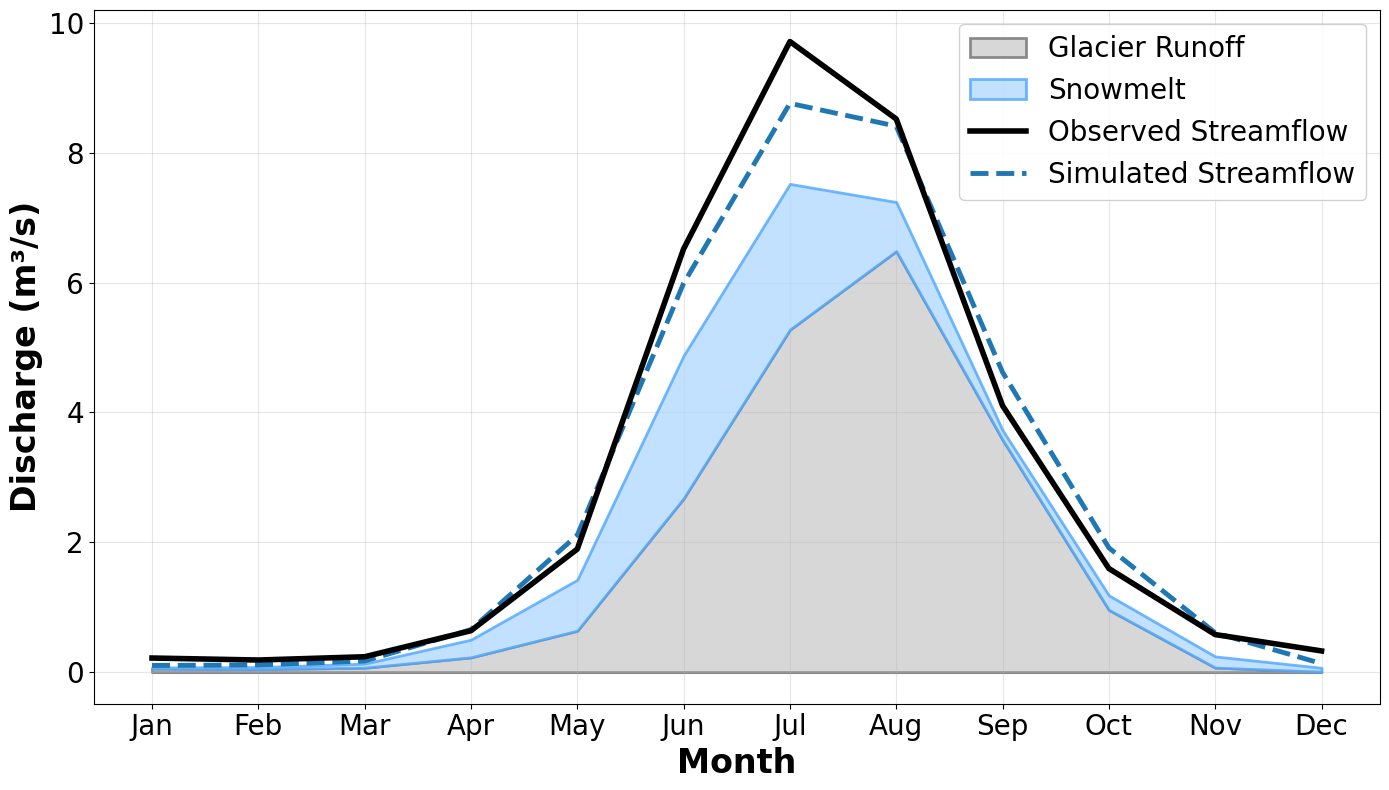

In [16]:
# Run the first plot (all glacier melt combined)
result1 = plot_streamflow_with_all_glacier_snowmelt_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

Creating streamflow regime with separated glacier melt and snowmelt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/2268_HBV_Hydrographs.csv
  - Found columns: sim=2268 [m3/s], obs=2268 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2000-01-02 00:00:00 to 2020-12-31 00:00:00
Loading snowmelt mass loadings for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded mass loadings: (7671, 4)
  - Columns: ['time[d]', 'date', 'hour', '2268 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2000-01-01 00:00:00 to 2020-12-31 00:00:00
  - Filtered to 4018 records
  - Zero snowmelt days: 472
  - Non-zero snowmelt days: 3546
  - Mean snowmelt: 0.5840 m³/s
  - Max snowmelt: 7.1734 m³/s
  - Sample values (first 5 days):
      2010-01-01: 0.0002 m³/s
      2010-01-02: 0.0002 m³/s
  

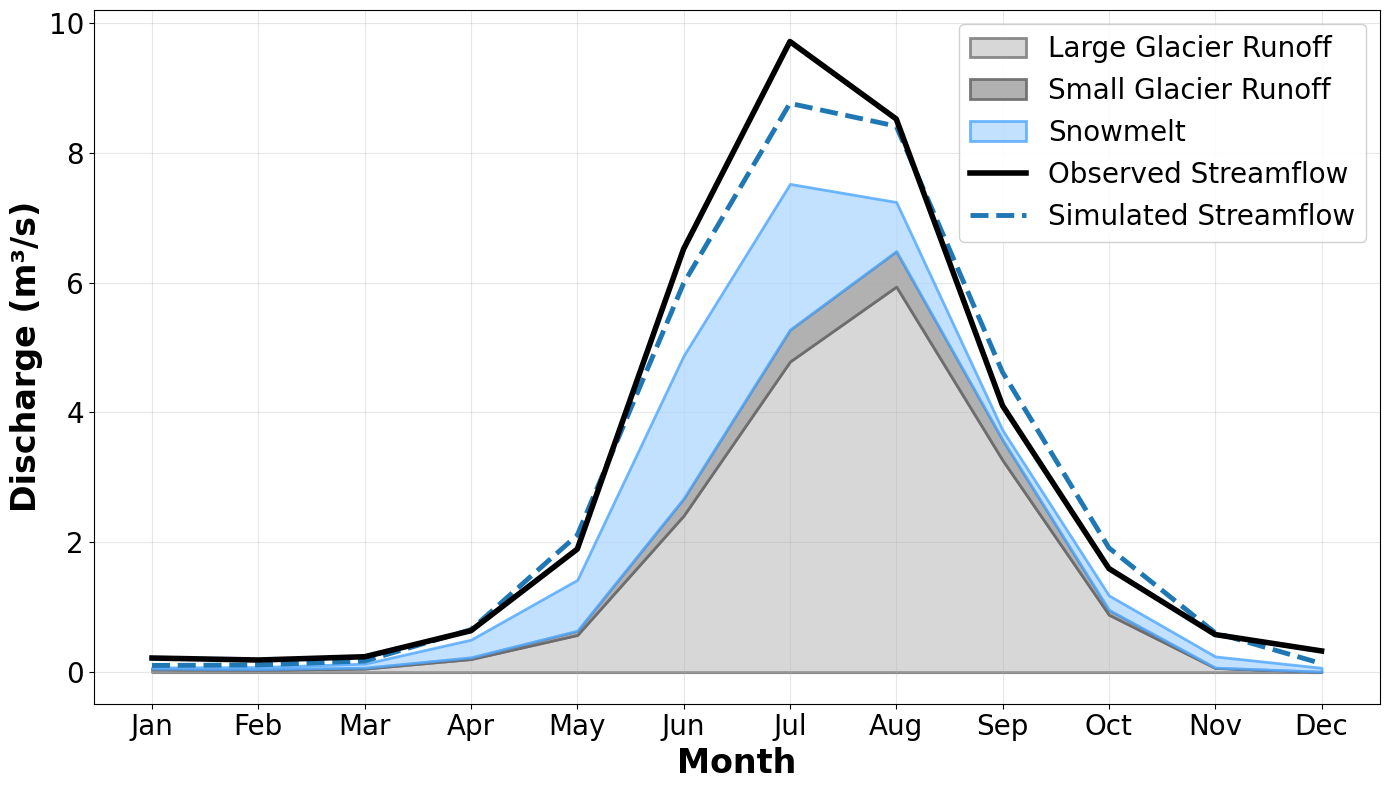

In [17]:
# Run the second plot (separated small/large glaciers)
result2 = plot_streamflow_with_separated_glacier_snowmelt_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [18]:
def plot_streamflow_with_all_glacier_snowmelt_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot streamflow regime with total glacier melt and snowmelt contributions.
    Shows: Simulated streamflow, Observed streamflow, Snowmelt, and Total Glacier Melt (ALL)
    """
    
    gauge_id = config['gauge_id']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Creating streamflow regime with all glacier melt and snowmelt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load streamflow data
    streamflow_data = load_hydrograph_data(config)
    if streamflow_data is None:
        print("ERROR: Could not load streamflow data")
        return None
    
    # Filter for validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    streamflow_mask = (streamflow_data['date'] >= start_date) & (streamflow_data['date'] <= end_date)
    streamflow_filtered = streamflow_data[streamflow_mask].copy()
    
    if len(streamflow_filtered) == 0:
        print(f"ERROR: No streamflow data found for period {validation_start} to {validation_end}")
        return None
    
    # Calculate monthly regime for streamflow
    streamflow_filtered['month'] = streamflow_filtered['date'].dt.month
    
    streamflow_regime = {}
    if 'obs_Q' in streamflow_filtered.columns:
        streamflow_regime['observed'] = streamflow_filtered.groupby('month')['obs_Q'].mean()
    if 'sim_Q' in streamflow_filtered.columns:
        streamflow_regime['simulated'] = streamflow_filtered.groupby('month')['sim_Q'].mean()
    
    # 2. Load snowmelt data
    snowmelt_df = load_snowmelt_mass_loadings(config, validation_start, validation_end)
    if snowmelt_df is None:
        print("ERROR: Could not load snowmelt data")
        return None
    
    # Calculate monthly regime for snowmelt
    snowmelt_df['month'] = snowmelt_df['date'].dt.month
    snowmelt_regime = snowmelt_df.groupby('month')['snowmelt_m3s'].mean()
    
    # 3. Load glacier melt data (ALL)
    glacier_data = load_glacier_melt_mass_loadings(config, validation_start, validation_end)
    if glacier_data is None or glacier_data.get('all') is None:
        print("ERROR: Could not load ALL glacier melt data")
        return None
    
    # Calculate monthly regime for ALL glacier melt
    glacier_all_df = glacier_data['all']
    glacier_all_df['month'] = glacier_all_df['date'].dt.month
    glacier_all_regime = glacier_all_df.groupby('month')['glacier_melt_m3s'].mean()
    
    # 4. Create plot
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot filled polygons OVERLAPPING (background to foreground)
    # Layer 1 (BACKGROUND): All glacier melt - light grey
    plt.fill_between(months, 0, glacier_all_regime.values, 
                     color='#D3D3D3', alpha=0.9, label='Glacier Runoff', zorder=1, 
                     edgecolor='#808080', linewidth=2)
    
    # Layer 2 (FOREGROUND): Snowmelt - light blue (on top)
    plt.fill_between(months, 0, snowmelt_regime.values, 
                     color='#B3D9FF', alpha=0.8, label='Snowmelt', zorder=2, 
                     edgecolor='#4DA6FF', linewidth=2)
    
    # Plot observed streamflow (line without markers)
    if 'observed' in streamflow_regime:
        plt.plot(months, streamflow_regime['observed'].values, 'k-', 
                linewidth=4, label='Observed Streamflow', zorder=4)
    
    # Plot simulated streamflow (dashed line without markers)
    if 'simulated' in streamflow_regime:
        plt.plot(months, streamflow_regime['simulated'].values, 'C0--', 
                linewidth=3.5, label='Simulated Streamflow', zorder=3)
    
    # Formatting with larger fonts
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Discharge (m³/s)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'streamflow_all_glacier_snowmelt_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved streamflow regime with all glacier melt plot to: {save_path}")
    plt.show()
    
    # Return all data
    return {
        'streamflow': streamflow_regime,
        'snowmelt': snowmelt_regime,
        'glacier_all': glacier_all_regime
    }


def plot_streamflow_with_separated_glacier_snowmelt_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot streamflow regime with separated glacier melt (SMALL, LARGE) and snowmelt contributions.
    """
    
    gauge_id = config['gauge_id']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Creating streamflow regime with separated glacier melt and snowmelt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load streamflow data
    streamflow_data = load_hydrograph_data(config)
    if streamflow_data is None:
        print("ERROR: Could not load streamflow data")
        return None
    
    # Filter for validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    streamflow_mask = (streamflow_data['date'] >= start_date) & (streamflow_data['date'] <= end_date)
    streamflow_filtered = streamflow_data[streamflow_mask].copy()
    
    if len(streamflow_filtered) == 0:
        print(f"ERROR: No streamflow data found for period {validation_start} to {validation_end}")
        return None
    
    # Calculate monthly regime for streamflow
    streamflow_filtered['month'] = streamflow_filtered['date'].dt.month
    
    streamflow_regime = {}
    if 'obs_Q' in streamflow_filtered.columns:
        streamflow_regime['observed'] = streamflow_filtered.groupby('month')['obs_Q'].mean()
    if 'sim_Q' in streamflow_filtered.columns:
        streamflow_regime['simulated'] = streamflow_filtered.groupby('month')['sim_Q'].mean()
    
    # 2. Load snowmelt data
    snowmelt_df = load_snowmelt_mass_loadings(config, validation_start, validation_end)
    if snowmelt_df is None:
        print("ERROR: Could not load snowmelt data")
        return None
    
    # Calculate monthly regime for snowmelt
    snowmelt_df['month'] = snowmelt_df['date'].dt.month
    snowmelt_regime = snowmelt_df.groupby('month')['snowmelt_m3s'].mean()
    
    # 3. Load glacier melt data (SMALL and LARGE)
    glacier_data = load_glacier_melt_mass_loadings(config, validation_start, validation_end)
    if glacier_data is None:
        print("ERROR: Could not load glacier melt data")
        return None
    
    # Calculate monthly regimes for SMALL and LARGE glacier melt
    glacier_regimes = {}
    
    if glacier_data.get('small') is not None:
        glacier_small_df = glacier_data['small']
        glacier_small_df['month'] = glacier_small_df['date'].dt.month
        glacier_regimes['small'] = glacier_small_df.groupby('month')['glacier_melt_m3s'].mean()
    else:
        print("WARNING: SMALL glacier data not available")
    
    if glacier_data.get('large') is not None:
        glacier_large_df = glacier_data['large']
        glacier_large_df['month'] = glacier_large_df['date'].dt.month
        glacier_regimes['large'] = glacier_large_df.groupby('month')['glacier_melt_m3s'].mean()
    else:
        print("WARNING: LARGE glacier data not available")
    
    if len(glacier_regimes) == 0:
        print("ERROR: No glacier melt data available")
        return None
    
    # 4. Create plot
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot filled polygons OVERLAPPING (background to foreground)
    # Layer 1 (BACKGROUND): Large glacier melt - light grey
    if 'large' in glacier_regimes:
        plt.fill_between(months, 0, glacier_regimes['large'].values, 
                        color='#D3D3D3', alpha=0.9, label='Large Glacier Runoff', zorder=1,
                        edgecolor='#808080', linewidth=2)
    
    # Layer 2 (MIDDLE): Snowmelt - light blue
    plt.fill_between(months, 0, snowmelt_regime.values, 
                     color='#B3D9FF', alpha=0.8, label='Snowmelt', zorder=2, 
                     edgecolor='#4DA6FF', linewidth=2)
    
    # Layer 3 (FOREGROUND): Small glacier melt - darker grey (on top)
    if 'small' in glacier_regimes:
        plt.fill_between(months, 0, glacier_regimes['small'].values, 
                        color='#A9A9A9', alpha=0.9, label='Small Glacier Runoff', zorder=3, 
                        edgecolor='#696969', linewidth=2)
    
    # Plot observed streamflow (line without markers)
    if 'observed' in streamflow_regime:
        plt.plot(months, streamflow_regime['observed'].values, 'k-', 
                linewidth=4, label='Observed Streamflow', zorder=5)
    
    # Plot simulated streamflow (dashed line without markers)
    if 'simulated' in streamflow_regime:
        plt.plot(months, streamflow_regime['simulated'].values, 'C0--', 
                linewidth=3.5, label='Simulated Streamflow', zorder=4)
    
    # Formatting with larger fonts
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Discharge (m³/s)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'streamflow_separated_glacier_snowmelt_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved streamflow regime with separated glacier melt plot to: {save_path}")
    plt.show()
    
    # Return all data
    return {
        'streamflow': streamflow_regime,
        'snowmelt': snowmelt_regime,
        'glacier_small': glacier_regimes.get('small'),
        'glacier_large': glacier_regimes.get('large')
    }

Creating streamflow regime with all glacier melt and snowmelt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/2268_HBV_Hydrographs.csv
  - Found columns: sim=2268 [m3/s], obs=2268 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2000-01-02 00:00:00 to 2020-12-31 00:00:00
Loading snowmelt mass loadings for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded mass loadings: (7671, 4)
  - Columns: ['time[d]', 'date', 'hour', '2268 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2000-01-01 00:00:00 to 2020-12-31 00:00:00
  - Filtered to 4018 records
  - Zero snowmelt days: 472
  - Non-zero snowmelt days: 3546
  - Mean snowmelt: 0.5840 m³/s
  - Max snowmelt: 7.1734 m³/s
  - Sample values (first 5 days):
      2010-01-01: 0.0002 m³/s
      2010-01-02: 0.0002 m³/s
      20

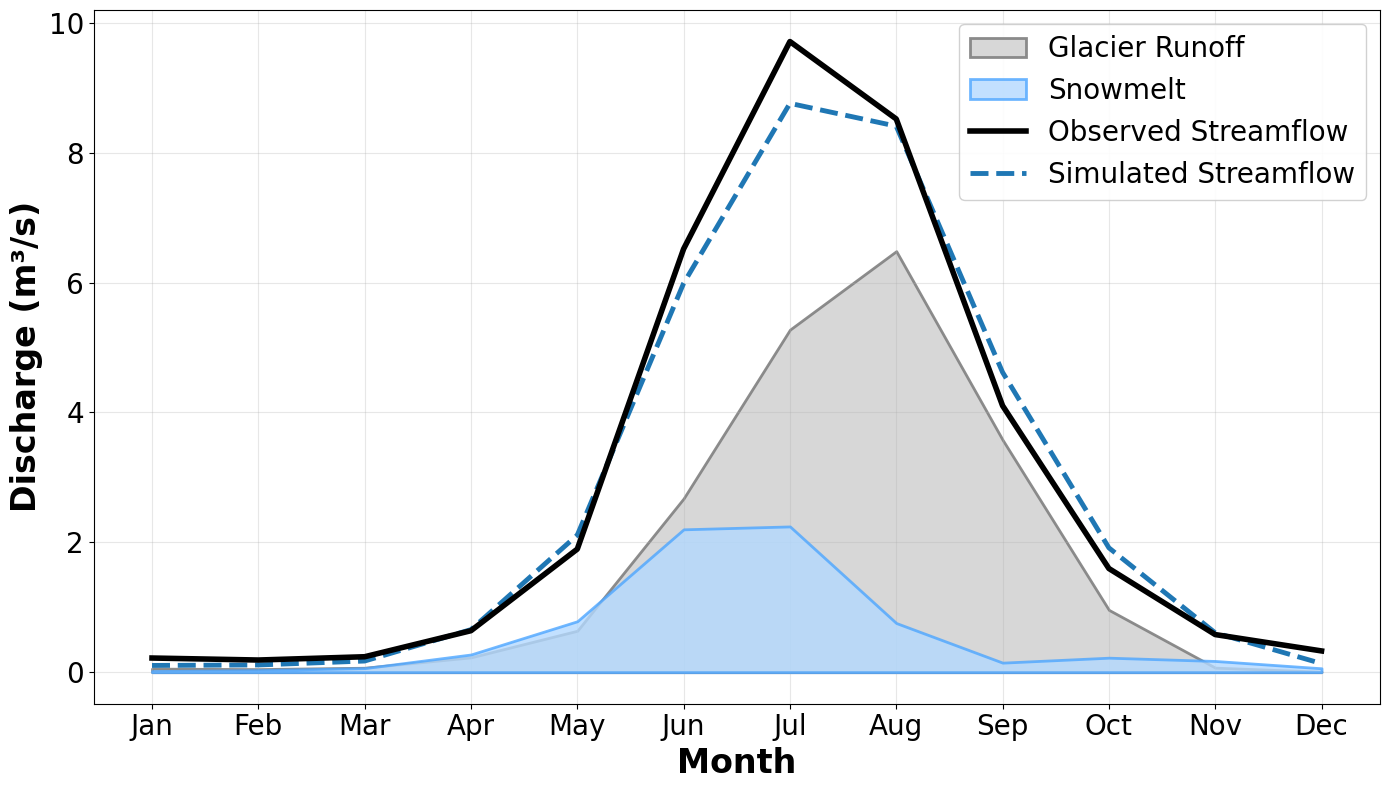

In [19]:
# Run the first plot (all glacier melt combined)
result1 = plot_streamflow_with_all_glacier_snowmelt_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

Creating streamflow regime with separated glacier melt and snowmelt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/2268_HBV_Hydrographs.csv
  - Found columns: sim=2268 [m3/s], obs=2268 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2000-01-02 00:00:00 to 2020-12-31 00:00:00
Loading snowmelt mass loadings for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded mass loadings: (7671, 4)
  - Columns: ['time[d]', 'date', 'hour', '2268 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2000-01-01 00:00:00 to 2020-12-31 00:00:00
  - Filtered to 4018 records
  - Zero snowmelt days: 472
  - Non-zero snowmelt days: 3546
  - Mean snowmelt: 0.5840 m³/s
  - Max snowmelt: 7.1734 m³/s
  - Sample values (first 5 days):
      2010-01-01: 0.0002 m³/s
      2010-01-02: 0.0002 m³/s
  

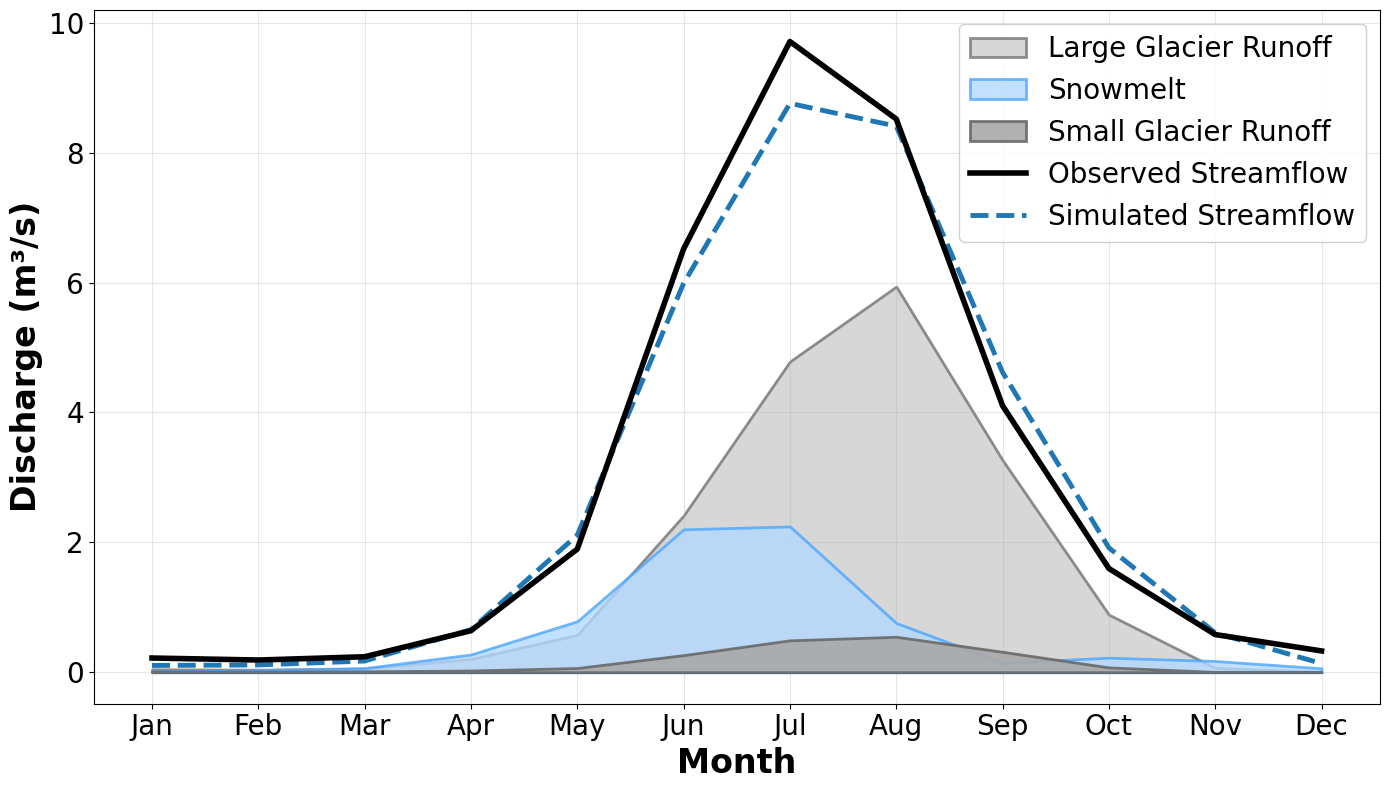

In [20]:
# Run the second plot (separated small/large glaciers)
result2 = plot_streamflow_with_separated_glacier_snowmelt_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [55]:
def plot_glogem_vs_raven_glacier_melt_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Compare GloGEM glacier melt output with Raven glacier melt mass loadings as monthly regimes.
    
    Parameters:
    -----------
    config : dict
        Configuration dictionary from namelist
    plot_dirs : dict
        Dictionary containing plot directory paths
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    gauge_id = config['gauge_id']
    config_dir = Path(config['main_dir']) / config['config_dir']
    
    print(f"Comparing GloGEM vs Raven glacier melt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load GloGEM parsed data
    topo_dir = config_dir / f"catchment_{gauge_id}" / "topo_files"
    glogem_file = topo_dir / f"GloGEM_parsed_{gauge_id}.csv"
    
    if not glogem_file.exists():
        print(f"ERROR: GloGEM parsed file not found: {glogem_file}")
        return None
    
    try:
        glogem_df = pd.read_csv(glogem_file)
        glogem_df['date'] = pd.to_datetime(glogem_df['date'])
        
        print(f"  ✓ Loaded GloGEM data: {len(glogem_df)} records")
        print(f"    Columns: {glogem_df.columns.tolist()}")
        
    except Exception as e:
        print(f"ERROR: Failed to load GloGEM data: {e}")
        return None
    
    # 2. Load Raven glacier melt mass loadings (ALL)
    model_dir = config_dir / f"catchment_{gauge_id}" / config['model_type']
    raven_glacier_file = model_dir / "output" / f"{gauge_id}_{config['model_type']}_GLACIERMELT_ALLMassLoadings.csv"
    
    if not raven_glacier_file.exists():
        print(f"ERROR: Raven glacier mass loadings file not found: {raven_glacier_file}")
        return None
    
    try:
        raven_df = pd.read_csv(raven_glacier_file)
        raven_df['date'] = pd.to_datetime(raven_df['date'])
        
        # Find the glacier melt column
        glacier_col = f"{gauge_id} m3/s"
        if glacier_col not in raven_df.columns:
            glacier_col = gauge_id
            if glacier_col not in raven_df.columns:
                print(f"ERROR: Could not find glacier melt column")
                print(f"Available columns: {raven_df.columns.tolist()}")
                return None
        
        raven_df['glacier_melt_m3s'] = raven_df[glacier_col]
        
        print(f"  ✓ Loaded Raven glacier data: {len(raven_df)} records")
        
    except Exception as e:
        print(f"ERROR: Failed to load Raven glacier data: {e}")
        return None
    
    # 3. Filter both datasets for validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    glogem_mask = (glogem_df['date'] >= start_date) & (glogem_df['date'] <= end_date)
    raven_mask = (raven_df['date'] >= start_date) & (raven_df['date'] <= end_date)
    
    glogem_filtered = glogem_df[glogem_mask].copy()
    raven_filtered = raven_df[raven_mask].copy()
    
    if len(glogem_filtered) == 0:
        print(f"ERROR: No GloGEM data for period {validation_start} to {validation_end}")
        return None
    
    if len(raven_filtered) == 0:
        print(f"ERROR: No Raven data for period {validation_start} to {validation_end}")
        return None
    
    print(f"  ✓ Filtered data: GloGEM={len(glogem_filtered)}, Raven={len(raven_filtered)} records")
    
    # 4. Calculate monthly regimes
    glogem_filtered['month'] = glogem_filtered['date'].dt.month
    raven_filtered['month'] = raven_filtered['date'].dt.month
    
    # For GloGEM: use 'total_output' column (already in mm/day)
    if 'total_output' not in glogem_filtered.columns:
        print(f"ERROR: 'total_output' column not found in GloGEM data")
        print(f"Available columns: {glogem_filtered.columns.tolist()}")
        return None
    
    glogem_regime = glogem_filtered.groupby('month')['total_output'].mean()
    
    # For Raven: convert m³/s to mm/day
    try:
        catchment_shape_file = topo_dir / "HRU.shp"
        if catchment_shape_file.exists():
            hru_gdf = gpd.read_file(catchment_shape_file)
            total_area_km2 = hru_gdf['Area_km2'].sum()
            # Convert m³/s to mm/day
            conversion_factor = 86400 / (total_area_km2 * 1000000) * 1000
            raven_filtered['glacier_melt_mm_day'] = raven_filtered['glacier_melt_m3s'] * conversion_factor
            print(f"  - Catchment area: {total_area_km2:.2f} km²")
            print(f"  - Conversion factor: {conversion_factor:.6f}")
        else:
            print("ERROR: Could not load catchment area for unit conversion")
            return None
    except Exception as e:
        print(f"ERROR: Failed to convert units: {e}")
        return None
    
    raven_regime = raven_filtered.groupby('month')['glacier_melt_mm_day'].mean()
    
    # 5. Create comparison plot
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot GloGEM regime
    plt.plot(months, glogem_regime.values, 
             color='#C17817', linewidth=3, marker='s', markersize=8,
             label='GloGEM Glacier Melt', zorder=3,linestyle='--')
    
    # Plot Raven regime
    plt.plot(months, raven_regime.values, 
             color='#246160', linewidth=3, marker='o', markersize=8,
             label='Raven Glacier Melt (ALL)', zorder=3)
    
    # Formatting
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('Glacier Melt (mm/day)', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=20, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'glogem_vs_raven_glacier_melt_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved comparison plot to: {save_path}")
    plt.show()
    
    # 6. Print summary statistics
    print(f"\nGlacier Melt Comparison Summary:")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"\n  GloGEM:")
    print(f"    Annual mean: {glogem_regime.sum() * 30.44:.1f} mm/year")
    print(f"    Peak month: {month_names[glogem_regime.idxmax()-1]} ({glogem_regime.max():.3f} mm/day)")
    print(f"    Min month: {month_names[glogem_regime.idxmin()-1]} ({glogem_regime.min():.3f} mm/day)")
    
    print(f"\n  Raven (ALL):")
    print(f"    Annual mean: {raven_regime.sum() * 30.44:.1f} mm/year")
    print(f"    Peak month: {month_names[raven_regime.idxmax()-1]} ({raven_regime.max():.3f} mm/day)")
    print(f"    Min month: {month_names[raven_regime.idxmin()-1]} ({raven_regime.min():.3f} mm/day)")
    
    # Calculate correlation and bias
    corr = np.corrcoef(glogem_regime.values, raven_regime.values)[0, 1]
    bias = (raven_regime.values - glogem_regime.values).mean()
    rmse = np.sqrt(np.mean((raven_regime.values - glogem_regime.values)**2))
    
    print(f"\n  Comparison metrics:")
    print(f"    Correlation: {corr:.3f}")
    print(f"    Bias (Raven - GloGEM): {bias:.3f} mm/day")
    print(f"    RMSE: {rmse:.3f} mm/day")
    
    return {
        'glogem_regime': glogem_regime,
        'raven_regime': raven_regime,
        'correlation': corr,
        'bias': bias,
        'rmse': rmse
    }

Comparing GloGEM vs Raven glacier melt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  ✓ Loaded GloGEM data: 7665 records
    Columns: ['date', 'glacier_melt', 'snowmelt', 'rainfall', 'total_output']
  ✓ Loaded Raven glacier data: 7671 records
  ✓ Filtered data: GloGEM=4015, Raven=4018 records
  - Catchment area: 39.25 km²
  - Conversion factor: 2.201149
Saved comparison plot to: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/plots/contributions/glogem_vs_raven_glacier_melt_regime_2268.png


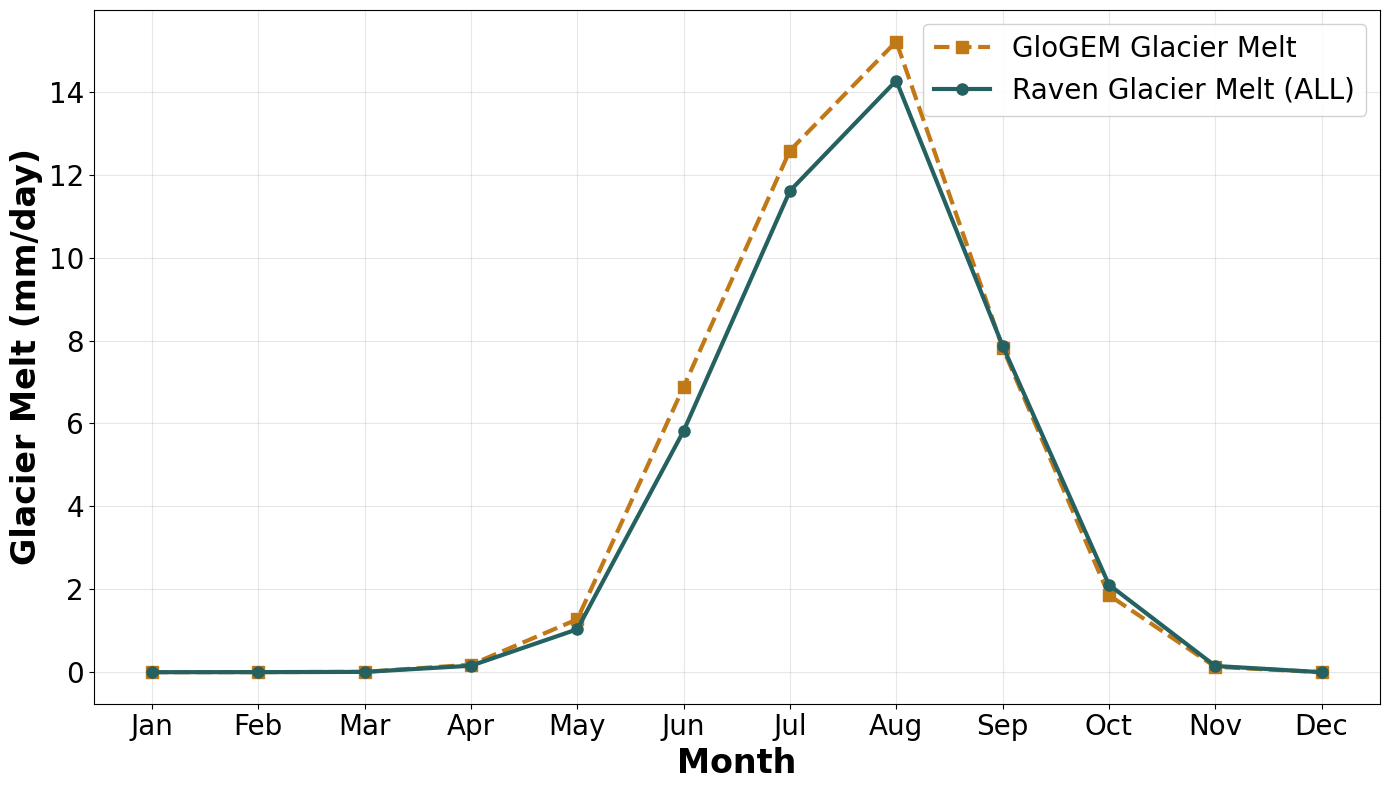


Glacier Melt Comparison Summary:
  Period: 2010-01-01 to 2020-12-31

  GloGEM:
    Annual mean: 1399.0 mm/year
    Peak month: Aug (15.213 mm/day)
    Min month: Jan (0.000 mm/day)

  Raven (ALL):
    Annual mean: 1310.1 mm/year
    Peak month: Aug (14.271 mm/day)
    Min month: Jan (0.000 mm/day)

  Comparison metrics:
    Correlation: 0.998
    Bias (Raven - GloGEM): -0.243 mm/day
    RMSE: 0.507 mm/day


In [56]:
# Run the comparison
comparison_result = plot_glogem_vs_raven_glacier_melt_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [37]:
def plot_glacier_precipitation_regime(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot area-weighted precipitation regime for glacier HRUs only, compared to catchment-wide precipitation.
    
    Parameters:
    -----------
    config : dict
        Configuration dictionary from namelist
    plot_dirs : dict
        Dictionary containing plot directory paths
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    import csv
    import geopandas as gpd
    
    gauge_id = config['gauge_id']
    model_type = config['model_type']
    config_dir = Path(config['main_dir']) / config['config_dir']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Plotting glacier precipitation regime for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # 1. Load HRU shapefile to identify glacier HRUs
    topo_dir = config_dir / f"catchment_{gauge_id}" / "topo_files"
    hru_shapefile = topo_dir / "HRU.shp"
    
    if not hru_shapefile.exists():
        print(f"ERROR: HRU shapefile not found: {hru_shapefile}")
        return None
    
    try:
        hru_gdf = gpd.read_file(hru_shapefile)
        print(f"  - Loaded {len(hru_gdf)} HRUs from shapefile")
    except Exception as e:
        print(f"ERROR: Failed to read HRU shapefile: {e}")
        return None
    
    # 2. Identify glacier HRUs (Landuse_Cl == 8)
    glacier_hrus = hru_gdf[hru_gdf['Landuse_Cl'] == 8].copy()
    
    if len(glacier_hrus) == 0:
        print("ERROR: No glacier HRUs found (Landuse_Cl == 8)")
        return None
    
    # Get glacier HRU IDs and areas
    glacier_hru_ids = glacier_hrus['HRU_ID'].astype(str).tolist()
    glacier_hru_areas = dict(zip(glacier_hrus['HRU_ID'].astype(str), glacier_hrus['Area_km2']))
    total_glacier_area = glacier_hrus['Area_km2'].sum()
    total_catchment_area = hru_gdf['Area_km2'].sum()
    glacier_fraction = total_glacier_area / total_catchment_area
    
    print(f"  - Found {len(glacier_hrus)} glacier HRUs")
    print(f"  - Total glacier area: {total_glacier_area:.2f} km² ({glacier_fraction*100:.1f}% of catchment)")
    print(f"  - Total catchment area: {total_catchment_area:.2f} km²")
    print(f"  - Glacier HRU IDs: {glacier_hru_ids}")
    
    # Get all HRU IDs and areas for catchment-wide calculation
    all_hru_ids = hru_gdf['HRU_ID'].astype(str).tolist()
    all_hru_areas = dict(zip(hru_gdf['HRU_ID'].astype(str), hru_gdf['Area_km2']))
    
    # 3. Load precipitation data
    model_dir = config_dir / f"catchment_{gauge_id}" / model_type
    precip_file = model_dir / "output" / f"{gauge_id}_{model_type}_PRECIP_Daily_Average_ByHRU.csv"
    
    if not precip_file.exists():
        print(f"ERROR: Precipitation file not found: {precip_file}")
        return None
    
    try:
        # Read header to get HRU ID mapping
        with open(precip_file, 'r') as f:
            reader = csv.reader(f)
            hru_id_row = next(reader)
            colname_row = next(reader)
        
        # Read the actual data
        precip_df = pd.read_csv(precip_file, header=1)
        
        print(f"  - Loaded precipitation data: {len(precip_df)} records")
        
    except Exception as e:
        print(f"ERROR: Failed to load precipitation data: {e}")
        return None
    
    # 4. Parse dates
    if 'date' in precip_df.columns:
        precip_df['date'] = pd.to_datetime(precip_df['date'])
    elif 'day' in precip_df.columns:
        precip_df['date'] = pd.to_datetime(precip_df['day'])
    else:
        print("ERROR: No date column found in precipitation file")
        return None
    
    # 5. Filter by validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    precip_mask = (precip_df['date'] >= start_date) & (precip_df['date'] <= end_date)
    precip_filtered = precip_df[precip_mask].copy()
    
    if len(precip_filtered) == 0:
        print(f"ERROR: No precipitation data for period {validation_start} to {validation_end}")
        return None
    
    print(f"  - Filtered to {len(precip_filtered)} records in validation period")
    
    # 6. Create mapping between column names and HRU IDs
    hru_colnames = [col for col in precip_df.columns if col not in ['time', 'date', 'day']]
    hru_id_map = dict(zip(hru_colnames, hru_id_row[2:]))  # skip time/date columns
    
    # 7. Find columns corresponding to glacier HRUs and all HRUs
    glacier_cols = [col for col in hru_colnames if hru_id_map[col] in glacier_hru_ids]
    all_cols = [col for col in hru_colnames if hru_id_map[col] in all_hru_ids]
    
    if not glacier_cols:
        print("ERROR: No glacier HRU columns found in precipitation file")
        print(f"  Available HRU IDs from file: {list(hru_id_map.values())[:10]}...")
        print(f"  Looking for glacier HRU IDs: {glacier_hru_ids}")
        return None
    
    print(f"  - Found {len(glacier_cols)} glacier HRU columns in precipitation data")
    print(f"  - Found {len(all_cols)} total HRU columns in precipitation data")
    
    # 8. Calculate area-weighted average precipitation over glacier HRUs
    precip_filtered['glacier_precip_weighted'] = 0.0
    
    for col in glacier_cols:
        hru_id = hru_id_map[col]
        hru_area = glacier_hru_areas[hru_id]
        weight = hru_area / total_glacier_area
        precip_filtered['glacier_precip_weighted'] += precip_filtered[col] * weight
    
    # 9. Calculate area-weighted average precipitation over ALL HRUs (catchment-wide)
    precip_filtered['catchment_precip_weighted'] = 0.0
    
    for col in all_cols:
        hru_id = hru_id_map[col]
        hru_area = all_hru_areas[hru_id]
        weight = hru_area / total_catchment_area
        precip_filtered['catchment_precip_weighted'] += precip_filtered[col] * weight
    
    # 10. Calculate area-scaled glacier precipitation (scaled to catchment area)
    precip_filtered['glacier_precip_area_scaled'] = precip_filtered['glacier_precip_weighted'] * glacier_fraction
    
    # 11. Calculate monthly regimes
    precip_filtered['month'] = precip_filtered['date'].dt.month
    glacier_regime = precip_filtered.groupby('month')['glacier_precip_weighted'].mean()
    catchment_regime = precip_filtered.groupby('month')['catchment_precip_weighted'].mean()
    glacier_regime_scaled = precip_filtered.groupby('month')['glacier_precip_area_scaled'].mean()
    
    # 12. Create plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Top plot: Glacier precipitation vs Catchment precipitation
    ax1.plot(months, glacier_regime.values, color='#4DA6FF', linewidth=3, marker='o', markersize=8,
            label=f'Glacier HRUs ({len(glacier_hrus)} HRUs, {glacier_fraction*100:.1f}% of area)', zorder=3)
    ax1.plot(months, catchment_regime.values, color='#2E8B57', linewidth=3, marker='s', markersize=8,
            label=f'Catchment Average ({len(hru_gdf)} HRUs)', zorder=2)
    
    ax1.set_xlabel('Month', fontsize=20, fontweight='bold')
    ax1.set_ylabel('Precipitation (mm/day)', fontsize=20, fontweight='bold')
    ax1.set_title(f'Precipitation on Glacier HRUs vs Catchment Average - Catchment {gauge_id}',
                 fontsize=18, fontweight='bold')
    ax1.set_xticks(months)
    ax1.set_xticklabels(month_names, fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=16, loc='best', framealpha=0.9)
    
    # Bottom plot: Area-scaled comparison
    ax2.plot(months, glacier_regime_scaled.values, color='#4DA6FF', linewidth=3, marker='o', markersize=8,
            label=f'Glacier Precip (area-scaled to catchment)', zorder=3)
    ax2.plot(months, catchment_regime.values, color='#2E8B57', linewidth=3, marker='s', markersize=8,
            label=f'Catchment Average', zorder=2)
    ax2.fill_between(months, 0, glacier_regime_scaled.values, color='#4DA6FF', alpha=0.3, zorder=1)
    
    ax2.set_xlabel('Month', fontsize=20, fontweight='bold')
    ax2.set_ylabel('Precipitation (mm/day)', fontsize=20, fontweight='bold')
    ax2.set_title(f'Area-Scaled Glacier Precipitation Contribution to Catchment',
                 fontsize=18, fontweight='bold')
    ax2.set_xticks(months)
    ax2.set_xticklabels(month_names, fontsize=16)
    ax2.tick_params(axis='y', labelsize=16)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=16, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'glacier_precipitation_regime_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved glacier precipitation regime plot to: {save_path}")
    plt.show()
    
    # 13. Print summary statistics
    glacier_annual = glacier_regime.sum() * 30.44
    catchment_annual = catchment_regime.sum() * 30.44
    glacier_scaled_annual = glacier_regime_scaled.sum() * 30.44
    
    print(f"\nGlacier Precipitation Analysis Summary:")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"  Number of glacier HRUs: {len(glacier_hrus)}")
    print(f"  Total glacier area: {total_glacier_area:.2f} km² ({glacier_fraction*100:.1f}% of catchment)")
    print(f"  Total catchment area: {total_catchment_area:.2f} km²")
    
    print(f"\n  Annual precipitation totals:")
    print(f"    Glacier HRUs: {glacier_annual:.1f} mm/year")
    print(f"    Catchment average: {catchment_annual:.1f} mm/year")
    print(f"    Glacier (area-scaled): {glacier_scaled_annual:.1f} mm/year")
    print(f"    Ratio (glacier/catchment): {glacier_annual/catchment_annual:.2f}")
    
    print(f"\n  Monthly statistics:")
    print(f"    Glacier - Peak: {month_names[glacier_regime.idxmax()-1]} ({glacier_regime.max():.2f} mm/day)")
    print(f"    Glacier - Min: {month_names[glacier_regime.idxmin()-1]} ({glacier_regime.min():.2f} mm/day)")
    print(f"    Catchment - Peak: {month_names[catchment_regime.idxmax()-1]} ({catchment_regime.max():.2f} mm/day)")
    print(f"    Catchment - Min: {month_names[catchment_regime.idxmin()-1]} ({catchment_regime.min():.2f} mm/day)")
    
    return {
        'glacier_regime': glacier_regime,
        'catchment_regime': catchment_regime,
        'glacier_regime_scaled': glacier_regime_scaled,
        'glacier_area': total_glacier_area,
        'catchment_area': total_catchment_area,
        'glacier_fraction': glacier_fraction,
        'glacier_annual': glacier_annual,
        'catchment_annual': catchment_annual,
        'glacier_scaled_annual': glacier_scaled_annual
    }

Plotting glacier precipitation regime for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded 60 HRUs from shapefile
  - Found 18 glacier HRUs
  - Total glacier area: 17.37 km² (44.2% of catchment)
  - Total catchment area: 39.25 km²
  - Glacier HRU IDs: ['3', '2', '1', '5', '6', '8', '7', '9', '11', '10', '13', '14', '15', '16', '17', '12', '4', '18']
  - Loaded precipitation data: 4803 records
  - Filtered to 1150 records in validation period
  - Found 18 glacier HRU columns in precipitation data
  - Found 60 total HRU columns in precipitation data
Saved glacier precipitation regime plot to: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/plots/contributions/glacier_precipitation_regime_2268.png


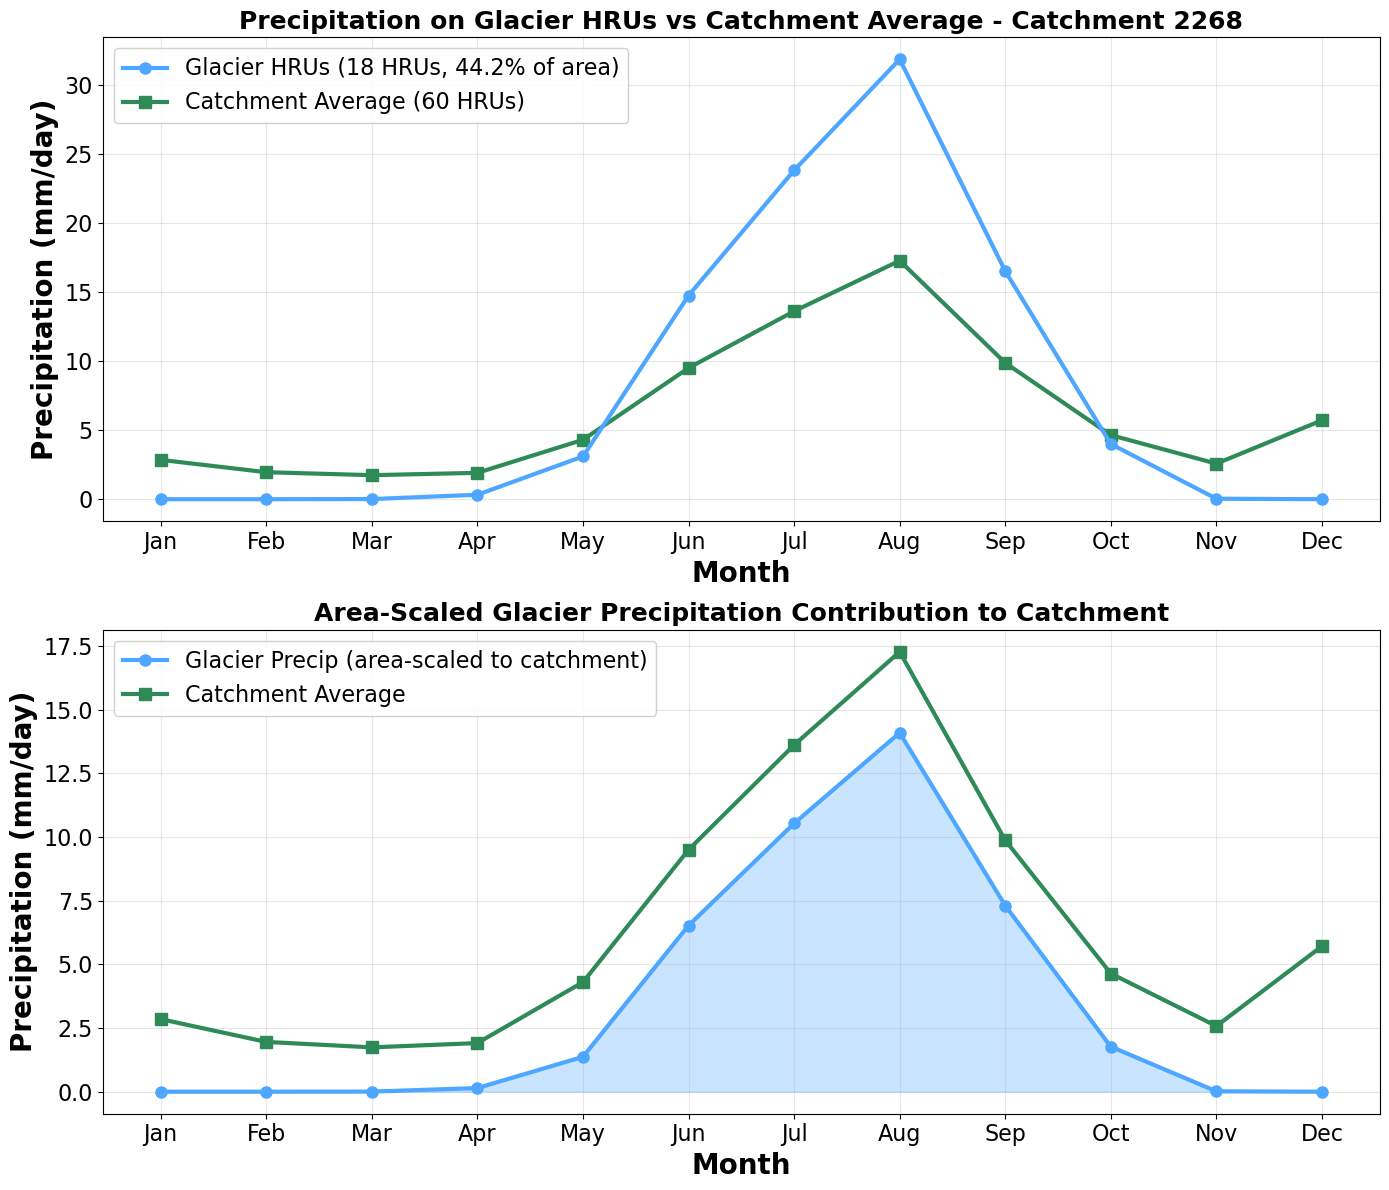


Glacier Precipitation Analysis Summary:
  Period: 2010-01-01 to 2020-12-31
  Number of glacier HRUs: 18
  Total glacier area: 17.37 km² (44.2% of catchment)
  Total catchment area: 39.25 km²

  Annual precipitation totals:
    Glacier HRUs: 2872.8 mm/year
    Catchment average: 2311.7 mm/year
    Glacier (area-scaled): 1271.2 mm/year
    Ratio (glacier/catchment): 1.24

  Monthly statistics:
    Glacier - Peak: Aug (31.84 mm/day)
    Glacier - Min: Jan (0.00 mm/day)
    Catchment - Peak: Aug (17.27 mm/day)
    Catchment - Min: Mar (1.74 mm/day)


In [38]:
# Example usage in notebook:
glacier_precip_result = plot_glacier_precipitation_regime(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [68]:
def plot_glacier_precipitation_vs_glacier_melt(config, plot_dirs, validation_start=None, validation_end=None):
    """
    Plot area-weighted glacier precipitation (catchment-scaled) vs Raven glacier melt (ALL).
    
    Parameters:
    -----------
    config : dict
        Configuration dictionary from namelist
    plot_dirs : dict
        Dictionary containing plot directory paths
    validation_start : str, optional
        Start date for validation period
    validation_end : str, optional
        End date for validation period
    """
    import csv
    import geopandas as gpd
    
    gauge_id = config['gauge_id']
    model_type = config['model_type']
    config_dir = Path(config['main_dir']) / config['config_dir']
    
    # Use dates from config if not provided
    if validation_start is None:
        validation_start = config.get('cali_end_date', '2010-01-01')
    if validation_end is None:
        validation_end = config.get('end_date', '2020-12-31')
    
    print(f"Plotting glacier precipitation vs glacier melt for catchment {gauge_id}:")
    print(f"  - Period: {validation_start} to {validation_end}")
    
    # =====================================================
    # 1. LOAD GLACIER PRECIPITATION DATA
    # =====================================================
    
    # Load HRU shapefile to identify glacier HRUs
    topo_dir = config_dir / f"catchment_{gauge_id}" / "topo_files"
    hru_shapefile = topo_dir / "HRU.shp"
    
    if not hru_shapefile.exists():
        print(f"ERROR: HRU shapefile not found: {hru_shapefile}")
        return None
    
    try:
        hru_gdf = gpd.read_file(hru_shapefile)
        print(f"  - Loaded {len(hru_gdf)} HRUs from shapefile")
    except Exception as e:
        print(f"ERROR: Failed to read HRU shapefile: {e}")
        return None
    
    # Identify glacier HRUs (Landuse_Cl == 8)
    glacier_hrus = hru_gdf[hru_gdf['Landuse_Cl'] == 8].copy()
    
    if len(glacier_hrus) == 0:
        print("ERROR: No glacier HRUs found (Landuse_Cl == 8)")
        return None
    
    # Get glacier HRU IDs and areas
    glacier_hru_ids = glacier_hrus['HRU_ID'].astype(str).tolist()
    glacier_hru_areas = dict(zip(glacier_hrus['HRU_ID'].astype(str), glacier_hrus['Area_km2']))
    total_glacier_area = glacier_hrus['Area_km2'].sum()
    total_catchment_area = hru_gdf['Area_km2'].sum()
    glacier_fraction = total_glacier_area / total_catchment_area
    
    print(f"  - Found {len(glacier_hrus)} glacier HRUs")
    print(f"  - Total glacier area: {total_glacier_area:.2f} km² ({glacier_fraction*100:.1f}% of catchment)")
    print(f"  - Total catchment area: {total_catchment_area:.2f} km²")
    
    # Load precipitation data
    model_dir = config_dir / f"catchment_{gauge_id}" / model_type
    precip_file = model_dir / "output" / f"{gauge_id}_{model_type}_PRECIP_Daily_Average_ByHRU.csv"
    
    if not precip_file.exists():
        print(f"ERROR: Precipitation file not found: {precip_file}")
        return None
    
    try:
        # Read header to get HRU ID mapping
        with open(precip_file, 'r') as f:
            reader = csv.reader(f)
            hru_id_row = next(reader)
            colname_row = next(reader)
        
        # Read the actual data
        precip_df = pd.read_csv(precip_file, header=1)
        
        print(f"  - Loaded precipitation data: {len(precip_df)} records")
        
    except Exception as e:
        print(f"ERROR: Failed to load precipitation data: {e}")
        return None
    
    # Parse dates
    if 'date' in precip_df.columns:
        precip_df['date'] = pd.to_datetime(precip_df['date'])
    elif 'day' in precip_df.columns:
        precip_df['date'] = pd.to_datetime(precip_df['day'])
    else:
        print("ERROR: No date column found in precipitation file")
        return None
    
    # Filter by validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    
    precip_mask = (precip_df['date'] >= start_date) & (precip_df['date'] <= end_date)
    precip_filtered = precip_df[precip_mask].copy()
    
    if len(precip_filtered) == 0:
        print(f"ERROR: No precipitation data for period {validation_start} to {validation_end}")
        return None
    
    # Create mapping between column names and HRU IDs
    hru_colnames = [col for col in precip_df.columns if col not in ['time', 'date', 'day']]
    hru_id_map = dict(zip(hru_colnames, hru_id_row[2:]))
    
    # Find columns corresponding to glacier HRUs
    glacier_cols = [col for col in hru_colnames if hru_id_map[col] in glacier_hru_ids]
    
    if not glacier_cols:
        print("ERROR: No glacier HRU columns found in precipitation file")
        return None
    
    print(f"  - Found {len(glacier_cols)} glacier HRU columns in precipitation data")
    
    # Calculate area-weighted average precipitation over glacier HRUs
    precip_filtered['glacier_precip_weighted'] = 0.0
    
    for col in glacier_cols:
        hru_id = hru_id_map[col]
        hru_area = glacier_hru_areas[hru_id]
        weight = hru_area / total_glacier_area
        precip_filtered['glacier_precip_weighted'] += precip_filtered[col] * weight
    
    # Calculate area-scaled glacier precipitation (scaled to catchment area)
    precip_filtered['glacier_precip_area_scaled'] = precip_filtered['glacier_precip_weighted'] * glacier_fraction
    
    # Calculate monthly regime for area-scaled glacier precipitation
    precip_filtered['month'] = precip_filtered['date'].dt.month
    glacier_precip_regime = precip_filtered.groupby('month')['glacier_precip_area_scaled'].mean()
    
    # =====================================================
    # 2. LOAD RAVEN GLACIER MELT DATA (ALL)
    # =====================================================
    
    raven_glacier_file = model_dir / "output" / f"{gauge_id}_{model_type}_GLACIERMELT_ALLMassLoadings.csv"
    
    if not raven_glacier_file.exists():
        print(f"ERROR: Raven glacier mass loadings file not found: {raven_glacier_file}")
        return None
    
    try:
        raven_df = pd.read_csv(raven_glacier_file)
        raven_df['date'] = pd.to_datetime(raven_df['date'])
        
        # Find the glacier melt column
        glacier_col = f"{gauge_id} m3/s"
        if glacier_col not in raven_df.columns:
            glacier_col = gauge_id
            if glacier_col not in raven_df.columns:
                print(f"ERROR: Could not find glacier melt column")
                print(f"Available columns: {raven_df.columns.tolist()}")
                return None
        
        raven_df['glacier_melt_m3s'] = raven_df[glacier_col]
        
        print(f"  ✓ Loaded Raven glacier melt data: {len(raven_df)} records")
        
    except Exception as e:
        print(f"ERROR: Failed to load Raven glacier data: {e}")
        return None
    
    # Filter by validation period
    raven_mask = (raven_df['date'] >= start_date) & (raven_df['date'] <= end_date)
    raven_filtered = raven_df[raven_mask].copy()
    
    if len(raven_filtered) == 0:
        print(f"ERROR: No Raven data for period {validation_start} to {validation_end}")
        return None
    
    # Convert m³/s to mm/day
    conversion_factor = 86400 / (total_catchment_area * 1000000) * 1000
    raven_filtered['glacier_melt_mm_day'] = raven_filtered['glacier_melt_m3s'] * conversion_factor
    
    print(f"  - Conversion factor (m³/s to mm/day): {conversion_factor:.6f}")
    
    # Calculate monthly regime for glacier melt
    raven_filtered['month'] = raven_filtered['date'].dt.month
    glacier_melt_regime = raven_filtered.groupby('month')['glacier_melt_mm_day'].mean()
    
    # =====================================================
    # 3. CREATE PLOT
    # =====================================================
    
    plt.figure(figsize=(14, 8))
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot glacier precipitation (area-scaled to catchment) - MULTIPLY BY 0.05
    plt.plot(months, glacier_precip_regime.values * 1.03, 
             color='#ef9b66', linewidth=3, marker='s', markersize=8,
             label=f'Glacier Runoff', 
             zorder=3,linestyle='--')
    
    # Plot glacier melt
    plt.plot(months, glacier_melt_regime.values, 
             color='#246160', linewidth=3, marker='o', markersize=8,
             label='Glacier Runoff Contributions', zorder=2,
             markeredgecolor='#246160', markeredgewidth=2)
    
    # Formatting
    plt.xlabel('Month', fontsize=24, fontweight='bold')
    plt.ylabel('mm/day', fontsize=24, fontweight='bold')
    plt.xticks(months, month_names, fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(fontsize=18, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    save_path = plot_dirs['contributions'] / f'glacier_precip_vs_melt_{gauge_id}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved glacier precipitation vs melt plot to: {save_path}")
    plt.show()
    
    # =====================================================
    # 4. PRINT SUMMARY STATISTICS
    # =====================================================
    
    glacier_precip_annual = glacier_precip_regime.sum() * 30.44
    glacier_melt_annual = glacier_melt_regime.sum() * 30.44
    
    print(f"\nGlacier Precipitation vs Glacier Melt Summary:")
    print(f"  Period: {validation_start} to {validation_end}")
    print(f"  Glacier area: {total_glacier_area:.2f} km² ({glacier_fraction*100:.1f}% of catchment)")
    
    print(f"\n  Annual totals:")
    print(f"    Glacier Runoff")
    print(f"    Glacier Melt: {glacier_melt_annual:.1f} mm/year")
    print(f"    Ratio (Melt/Precip): {glacier_melt_annual/glacier_precip_annual:.2f}")
    
    print(f"\n  Peak months:")
    print(f"    Glacier Precipitation: {month_names[glacier_precip_regime.idxmax()-1]} ({glacier_precip_regime.max():.3f} mm/day)")
    print(f"    Glacier Melt: {month_names[glacier_melt_regime.idxmax()-1]} ({glacier_melt_regime.max():.3f} mm/day)")
    
    # Calculate net balance (Precip - Melt)
    net_balance_regime = glacier_precip_regime.values - glacier_melt_regime.values
    net_balance_annual = net_balance_regime.sum() * 30.44
    
    print(f"\n  Net balance (Precip - Melt):")
    print(f"    Annual: {net_balance_annual:.1f} mm/year")
    print(f"    Peak accumulation month: {month_names[np.argmax(net_balance_regime)]} ({net_balance_regime.max():.3f} mm/day)")
    print(f"    Peak ablation month: {month_names[np.argmin(net_balance_regime)]} ({net_balance_regime.min():.3f} mm/day)")
    
    return {
        'glacier_precip_regime': glacier_precip_regime,
        'glacier_melt_regime': glacier_melt_regime,
        'glacier_area': total_glacier_area,
        'catchment_area': total_catchment_area,
        'glacier_fraction': glacier_fraction,
        'glacier_precip_annual': glacier_precip_annual,
        'glacier_melt_annual': glacier_melt_annual,
        'net_balance_annual': net_balance_annual,
        'net_balance_regime': net_balance_regime
    }

Plotting glacier precipitation vs glacier melt for catchment 2268:
  - Period: 2010-01-01 to 2020-12-31
  - Loaded 60 HRUs from shapefile
  - Found 18 glacier HRUs
  - Total glacier area: 17.37 km² (44.2% of catchment)
  - Total catchment area: 39.25 km²
  - Loaded precipitation data: 4803 records
  - Found 18 glacier HRU columns in precipitation data
  ✓ Loaded Raven glacier melt data: 7671 records
  - Conversion factor (m³/s to mm/day): 2.201149

Saved glacier precipitation vs melt plot to: /home/jberg/OneDrive/Raven_Switzerland/04_runs_final_paperdraft_without2109/02_model_setups_coupled_sr/catchment_2268/HBV/output/plots/contributions/glacier_precip_vs_melt_2268.png


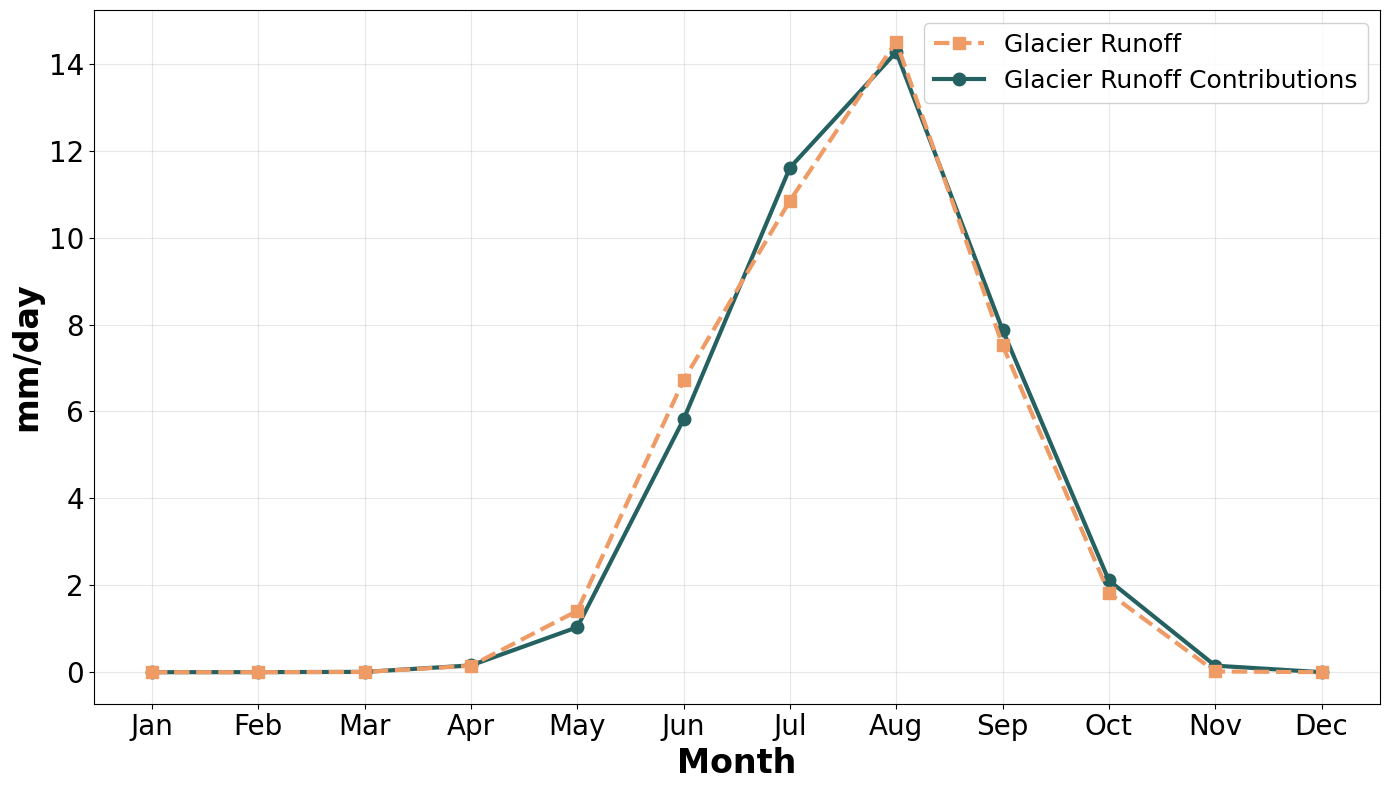


Glacier Precipitation vs Glacier Melt Summary:
  Period: 2010-01-01 to 2020-12-31
  Glacier area: 17.37 km² (44.2% of catchment)

  Annual totals:
    Glacier Runoff
    Glacier Melt: 1310.1 mm/year
    Ratio (Melt/Precip): 1.03

  Peak months:
    Glacier Precipitation: Aug (14.091 mm/day)
    Glacier Melt: Aug (14.271 mm/day)

  Net balance (Precip - Melt):
    Annual: -39.0 mm/year
    Peak accumulation month: Jun (0.706 mm/day)
    Peak ablation month: Jul (-1.076 mm/day)


In [69]:
# Example usage in notebook:
glacier_precip_melt_result = plot_glacier_precipitation_vs_glacier_melt(
    config, 
    plot_dirs,
    validation_start='2010-01-01',
    validation_end='2020-12-31'
)

In [8]:
# ...existing code...

def plot_multi_model_streamflow_regime(catchment_dir, gauge_id, validation_start=None, validation_end=None,
                                      model_types=['HBV', 'HYMOD', 'MOHYSE', 'HMETS'],
                                      save_dir=None, figsize=(16, 10)):
    """
    Compare streamflow regimes from different model types for a single catchment.
    Creates a presentation-ready plot with observed streamflow and up to 4 model simulations.
    
    Parameters:
    -----------
    catchment_dir : str or Path
        Path to catchment directory (e.g., '/path/to/catchment_0102_snowline')
    gauge_id : str
        Gauge ID (e.g., '0102')
    validation_start : str, optional
        Start date for validation period (e.g., '2010-01-01')
    validation_end : str, optional
        End date for validation period (e.g., '2020-12-31')
    model_types : list, optional
        List of model types to check (default: ['HBV', 'HYMOD', 'MOHYSE', 'HMETS'])
    save_dir : str or Path, optional
        Directory to save the plot (default: catchment_dir/plots)
    figsize : tuple, optional
        Figure size (default: (16, 10))
        
    Returns:
    --------
    dict
        Dictionary containing monthly regime data for each model and observed data
    """
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    
    catchment_dir = Path(catchment_dir)
    
    print(f"Creating multi-model streamflow regime comparison:")
    print(f"  - Catchment directory: {catchment_dir}")
    print(f"  - Gauge ID: {gauge_id}")
    print(f"  - Validation period: {validation_start} to {validation_end}")
    
    # Define colors for each model type
    model_colors = {
        'HBV': '#246160',      # Teal
        'HYMOD': '#C17817',    # Orange/Brown
        'MOHYSE': '#976c03',   # Dark Gold
        'HMETS': '#ef9b66'     # Light Orange
    }
    
    # Define line styles for variety
    model_linestyles = {
        'HBV': '-',
        'HYMOD': '--',
        'MOHYSE': '-.',
        'HMETS': ':'
    }
    
    # Dictionary to store results
    regime_data = {}
    obs_regime = None
    successful_models = []
    failed_models = []
    
    # Load data from each model type
    for model_type in model_types:
        model_dir = catchment_dir / model_type
        
        # Check if model directory exists
        if not model_dir.exists():
            print(f"  - {model_type}: Directory not found, skipping")
            failed_models.append((model_type, "Directory not found"))
            continue
        
        # Look for hydrograph file
        output_dir = model_dir / "output"
        if not output_dir.exists():
            print(f"  - {model_type}: Output directory not found, skipping")
            failed_models.append((model_type, "Output directory not found"))
            continue
        
        # Find hydrograph file
        hydro_file = output_dir / f"{gauge_id}_{model_type}_Hydrographs.csv"
        
        if not hydro_file.exists():
            print(f"  - {model_type}: Hydrograph file not found, skipping")
            failed_models.append((model_type, "Hydrograph file not found"))
            continue
        
        try:
            # Read hydrograph file
            df = pd.read_csv(hydro_file, skiprows=[1])
            
            # Convert date column to datetime
            if 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
            else:
                print(f"  - {model_type}: No date column found, skipping")
                failed_models.append((model_type, "No date column"))
                continue
            
            # Find simulated and observed columns
            sim_col = None
            obs_col = None
            
            for col in df.columns:
                if '[m3/s]' in col and 'observed' not in col.lower():
                    sim_col = col
                elif '[m3/s]' in col and 'observed' in col.lower():
                    obs_col = col
            
            if sim_col is None:
                print(f"  - {model_type}: No simulated discharge column found, skipping")
                failed_models.append((model_type, "No simulated discharge column"))
                continue
            
            # Rename columns for consistency
            df['sim_Q'] = df[sim_col]
            if obs_col:
                df['obs_Q'] = df[obs_col]
            
            # Filter for validation period
            if validation_start and validation_end:
                start_date = pd.to_datetime(validation_start)
                end_date = pd.to_datetime(validation_end)
                mask = (df['date'] >= start_date) & (df['date'] <= end_date)
                df_filtered = df[mask].copy()
            else:
                df_filtered = df.copy()
            
            if len(df_filtered) == 0:
                print(f"  - {model_type}: No data in validation period, skipping")
                failed_models.append((model_type, "No data in validation period"))
                continue
            
            # Calculate monthly regime
            df_filtered['month'] = df_filtered['date'].dt.month
            sim_regime = df_filtered.groupby('month')['sim_Q'].mean()
            
            # Store regime data
            regime_data[model_type] = sim_regime
            successful_models.append(model_type)
            
            # Store observed data (only once)
            if obs_regime is None and obs_col:
                obs_regime = df_filtered.groupby('month')['obs_Q'].mean()
            
            print(f"  ✓ {model_type}: Successfully loaded data")
            print(f"    - Mean discharge: {sim_regime.mean():.3f} m³/s")
            print(f"    - Peak month: {sim_regime.idxmax()}")
            
        except Exception as e:
            print(f"  - {model_type}: Error loading data: {e}")
            failed_models.append((model_type, str(e)))
            continue
    
    # Check if we have any data to plot
    if len(successful_models) == 0:
        print("\n❌ ERROR: No model data could be loaded!")
        print("\nFailed models:")
        for model, reason in failed_models:
            print(f"  - {model}: {reason}")
        return None
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    months = range(1, 13)
    month_names_short = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    
    # Plot observed streamflow first (if available)
    if obs_regime is not None:
        plt.plot(months, obs_regime.reindex(months).values, 'k-', 
                linewidth=6, label='Observed', zorder=10)
        print(f"\n  ✓ Plotted observed streamflow")
        print(f"    - Mean discharge: {obs_regime.mean():.3f} m³/s")
    else:
        print(f"\n  ⚠️  No observed streamflow data available")
    
    # Plot each model's simulated streamflow
    for model_type in successful_models:
        sim_regime = regime_data[model_type]
        plt.plot(months, sim_regime.reindex(months).values, 
                color=model_colors.get(model_type, 'gray'),
                linestyle=model_linestyles.get(model_type, '-'),
                linewidth=4, 
                label=model_type, 
                zorder=8)
    
    # Formatting for presentation
    plt.ylabel('Discharge (m³/s)', fontsize=32, fontweight='bold')
    plt.xticks(months, month_names_short, fontsize=32, fontweight='bold')
    plt.yticks(fontsize=32, fontweight='bold')
    plt.grid(True, alpha=0.3, zorder=0)
    plt.legend(loc='best', fontsize=28, framealpha=0.9)
    
    plt.tight_layout()
    
    # Save plot
    if save_dir is None:
        save_dir = catchment_dir / "plots"
    else:
        save_dir = Path(save_dir)
    
    save_dir.mkdir(parents=True, exist_ok=True)
    
    period_str = f"{validation_start.replace('-', '')}_{validation_end.replace('-', '')}" if validation_start and validation_end else "all"
    save_path = save_dir / f'multi_model_streamflow_regime_{gauge_id}_{period_str}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Saved plot to: {save_path}")
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"MULTI-MODEL STREAMFLOW REGIME SUMMARY")
    print(f"{'='*60}")
    print(f"Catchment: {gauge_id}")
    print(f"Validation period: {validation_start} to {validation_end}")
    print(f"Successful models: {len(successful_models)}/{len(model_types)}")
    print(f"  Models loaded: {', '.join(successful_models)}")
    
    if failed_models:
        print(f"\nFailed models: {len(failed_models)}")
        for model, reason in failed_models:
            print(f"  - {model}: {reason}")
    
    if obs_regime is not None:
        print(f"\nObserved streamflow:")
        print(f"  Mean: {obs_regime.mean():.3f} m³/s")
        print(f"  Peak: {month_names_short[obs_regime.idxmax()-1]} ({obs_regime.max():.3f} m³/s)")
        print(f"  Min: {month_names_short[obs_regime.idxmin()-1]} ({obs_regime.min():.3f} m³/s)")
    
    print(f"\nSimulated streamflow comparison:")
    for model_type in successful_models:
        sim_regime = regime_data[model_type]
        if obs_regime is not None:
            bias = sim_regime.mean() - obs_regime.mean()
            bias_pct = (bias / obs_regime.mean()) * 100
            print(f"  {model_type:8s}: Mean={sim_regime.mean():.3f} m³/s, "
                  f"Bias={bias:+.3f} m³/s ({bias_pct:+.1f}%)")
        else:
            print(f"  {model_type:8s}: Mean={sim_regime.mean():.3f} m³/s")
    
    print(f"{'='*60}")
    
    # Return results
    return {
        'observed': obs_regime,
        'simulated': regime_data,
        'successful_models': successful_models,
        'failed_models': failed_models,
        'save_path': save_path,
        'catchment_id': gauge_id,
        'validation_period': {
            'start': validation_start,
            'end': validation_end
        }
    }

Creating multi-model streamflow regime comparison:
  - Catchment directory: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102
  - Gauge ID: 0102
  - Validation period: 1995-01-01 to 2000-12-31
  ✓ HBV: Successfully loaded data
    - Mean discharge: 503.791 m³/s
    - Peak month: 8
  ✓ HYMOD: Successfully loaded data
    - Mean discharge: 548.129 m³/s
    - Peak month: 8
  ✓ MOHYSE: Successfully loaded data
    - Mean discharge: 536.034 m³/s
    - Peak month: 8
  - HMETS: Output directory not found, skipping

  ✓ Plotted observed streamflow
    - Mean discharge: 274.556 m³/s

✓ Saved plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/plots/multi_model_streamflow_regime_0102_19950101_20001231.png


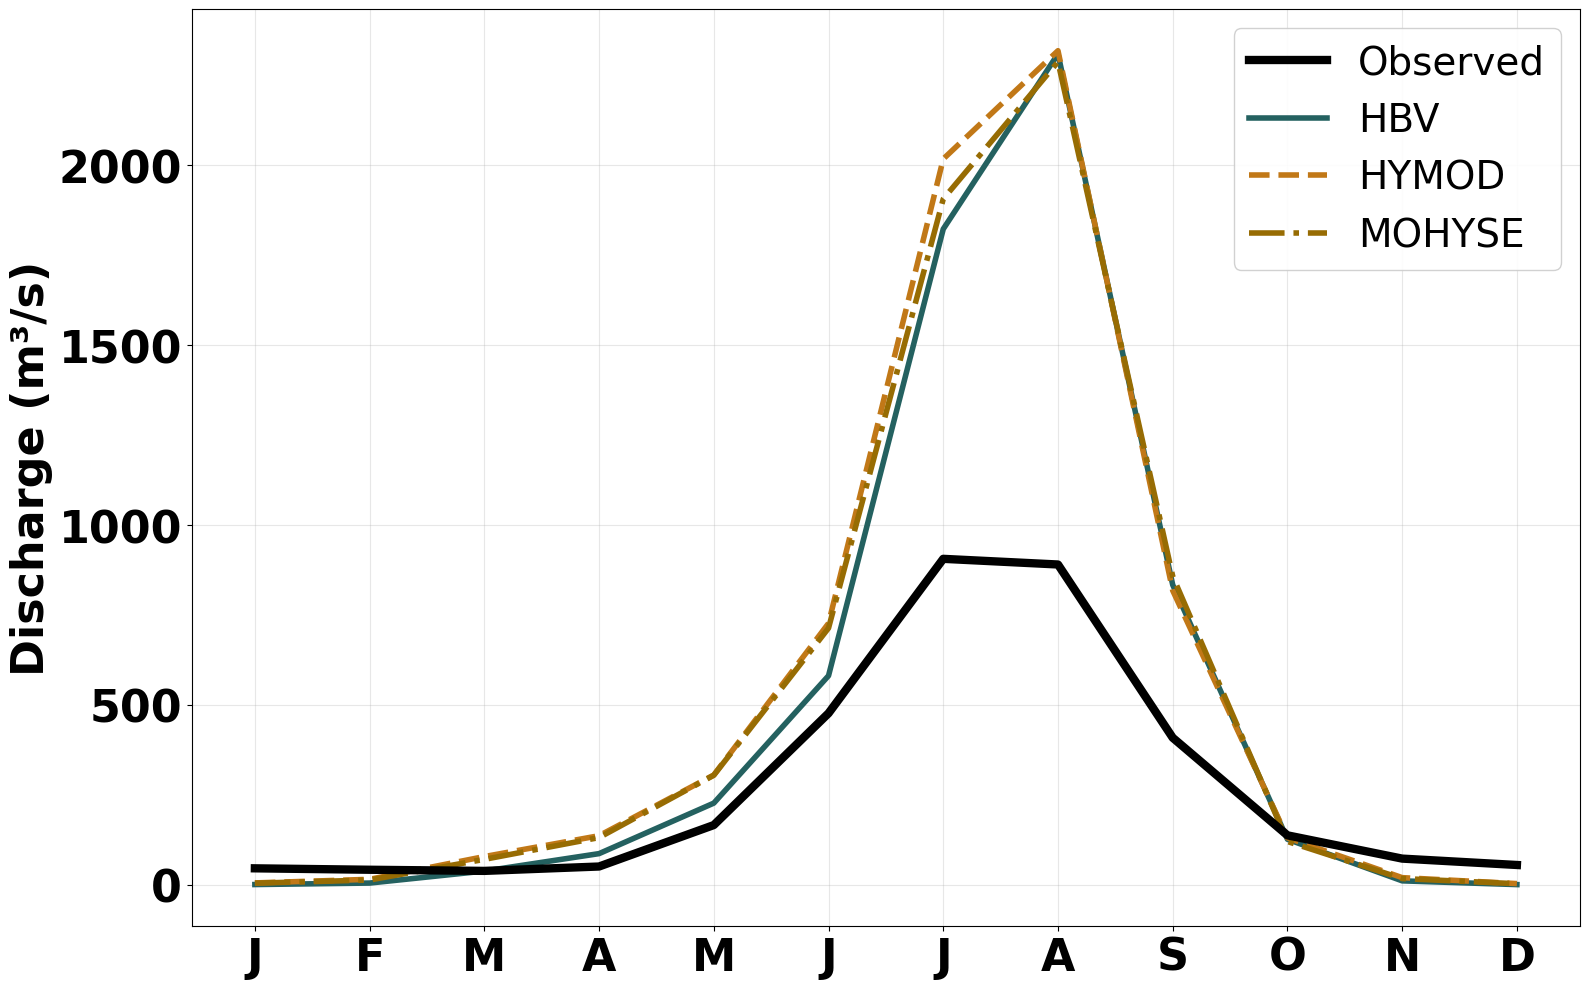


MULTI-MODEL STREAMFLOW REGIME SUMMARY
Catchment: 0102
Validation period: 1995-01-01 to 2000-12-31
Successful models: 3/4
  Models loaded: HBV, HYMOD, MOHYSE

Failed models: 1
  - HMETS: Output directory not found

Observed streamflow:
  Mean: 274.556 m³/s
  Peak: J (906.043 m³/s)
  Min: M (39.131 m³/s)

Simulated streamflow comparison:
  HBV     : Mean=503.791 m³/s, Bias=+229.236 m³/s (+83.5%)
  HYMOD   : Mean=548.129 m³/s, Bias=+273.573 m³/s (+99.6%)
  MOHYSE  : Mean=536.034 m³/s, Bias=+261.478 m³/s (+95.2%)


In [9]:
# Example usage
result = plot_multi_model_streamflow_regime(
    catchment_dir='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102',
    gauge_id='0102',
    validation_start='1995-01-01',
    validation_end='2000-12-31',
    model_types=['HBV', 'HYMOD', 'MOHYSE', 'HMETS']
)

In [10]:
def plot_multi_model_streamflow_with_separated_contributions(
    catchment_dir, 
    gauge_id, 
    validation_start=None, 
    validation_end=None,
    model_types=['HBV', 'HYMOD', 'MOHYSE', 'HMETS'],
    save_dir=None, 
    figsize=None
):
    """
    Plot streamflow regimes with separated glacier melt and snowmelt contributions
    for multiple model configurations in separate panels.
    
    Parameters:
    -----------
    catchment_dir : str or Path
        Path to catchment directory (e.g., '/path/to/catchment_0102')
    gauge_id : str
        Gauge ID (e.g., '0102')
    validation_start : str, optional
        Start date for validation period (e.g., '2010-01-01')
    validation_end : str, optional
        End date for validation period (e.g., '2020-12-31')
    model_types : list, optional
        List of model types to check (default: ['HBV', 'HYMOD', 'MOHYSE', 'HMETS'])
    save_dir : str or Path, optional
        Directory to save the plot (default: catchment_dir/plots)
    figsize : tuple, optional
        Figure size (default: auto-calculated based on number of models)
        
    Returns:
    --------
    dict
        Dictionary containing regime data for each model
    """
    
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    import geopandas as gpd
    
    catchment_dir = Path(catchment_dir)
    
    print(f"Creating multi-model streamflow regime with contributions:")
    print(f"  - Catchment directory: {catchment_dir}")
    print(f"  - Gauge ID: {gauge_id}")
    print(f"  - Validation period: {validation_start} to {validation_end}")
    print(f"  - Looking for models: {model_types}")
    
    # Dictionary to store results for each model
    model_data = {}
    successful_models = []
    failed_models = []
    
    # Load each model's data
    for model_type in model_types:
        model_dir = catchment_dir / model_type
        
        if not model_dir.exists():
            print(f"  - {model_type}: Directory not found, skipping")
            failed_models.append((model_type, "Directory not found"))
            continue
        
        print(f"\n  Loading {model_type} data...")
        
        try:
            # 1. Load streamflow (hydrograph)
            output_dir = model_dir / "output"
            hydro_file = output_dir / f"{gauge_id}_{model_type}_Hydrographs.csv"
            
            if not hydro_file.exists():
                print(f"    ✗ Hydrograph file not found")
                failed_models.append((model_type, "Hydrograph file not found"))
                continue
            
            # Read hydrograph
            hydro_df = pd.read_csv(hydro_file, skiprows=[1])
            hydro_df['date'] = pd.to_datetime(hydro_df['date'])
            
            # Find columns
            sim_col = None
            obs_col = None
            for col in hydro_df.columns:
                if '[m3/s]' in col and 'observed' not in col.lower():
                    sim_col = col
                elif '[m3/s]' in col and 'observed' in col.lower():
                    obs_col = col
            
            if sim_col is None:
                print(f"    ✗ No simulated discharge column found")
                failed_models.append((model_type, "No simulated discharge column"))
                continue
            
            hydro_df['sim_Q'] = hydro_df[sim_col]
            if obs_col:
                hydro_df['obs_Q'] = hydro_df[obs_col]
            
            # 2. Load snowmelt mass loadings
            snowmelt_file = output_dir / f"{gauge_id}_{model_type}_SNOWMELTMassLoadings.csv"
            
            if not snowmelt_file.exists():
                print(f"    ✗ Snowmelt file not found")
                failed_models.append((model_type, "Snowmelt file not found"))
                continue
            
            snowmelt_df = pd.read_csv(snowmelt_file)
            snowmelt_df['date'] = pd.to_datetime(snowmelt_df['date'])
            
            # Find snowmelt column
            snowmelt_col = f"{gauge_id} m3/s"
            if snowmelt_col not in snowmelt_df.columns:
                snowmelt_col = gauge_id
            
            if snowmelt_col not in snowmelt_df.columns:
                print(f"    ✗ Snowmelt data column not found")
                failed_models.append((model_type, "Snowmelt data column not found"))
                continue
            
            snowmelt_df['snowmelt_m3s'] = snowmelt_df[snowmelt_col]
            
            # 3. Load glacier melt mass loadings (SMALL and LARGE)
            glacier_small_file = output_dir / f"{gauge_id}_{model_type}_GLACIERMELT_SMALLMassLoadings.csv"
            glacier_large_file = output_dir / f"{gauge_id}_{model_type}_GLACIERMELT_LARGEMassLoadings.csv"
            
            glacier_regimes = {}
            
            # Load SMALL glaciers
            if glacier_small_file.exists():
                glacier_small_df = pd.read_csv(glacier_small_file)
                glacier_small_df['date'] = pd.to_datetime(glacier_small_df['date'])
                
                glacier_col = f"{gauge_id} m3/s"
                if glacier_col not in glacier_small_df.columns:
                    glacier_col = gauge_id
                
                if glacier_col in glacier_small_df.columns:
                    glacier_small_df['glacier_melt_m3s'] = glacier_small_df[glacier_col]
                    glacier_regimes['small'] = glacier_small_df
                    print(f"    ✓ Loaded SMALL glacier data")
            
            # Load LARGE glaciers
            if glacier_large_file.exists():
                glacier_large_df = pd.read_csv(glacier_large_file)
                glacier_large_df['date'] = pd.to_datetime(glacier_large_df['date'])
                
                glacier_col = f"{gauge_id} m3/s"
                if glacier_col not in glacier_large_df.columns:
                    glacier_col = gauge_id
                
                if glacier_col in glacier_large_df.columns:
                    glacier_large_df['glacier_melt_m3s'] = glacier_large_df[glacier_col]
                    glacier_regimes['large'] = glacier_large_df
                    print(f"    ✓ Loaded LARGE glacier data")
            
            if len(glacier_regimes) == 0:
                print(f"    ✗ No glacier melt data found")
                failed_models.append((model_type, "No glacier melt data"))
                continue
            
            # 4. Filter all data for validation period
            if validation_start and validation_end:
                start_date = pd.to_datetime(validation_start)
                end_date = pd.to_datetime(validation_end)
                
                hydro_mask = (hydro_df['date'] >= start_date) & (hydro_df['date'] <= end_date)
                hydro_df = hydro_df[hydro_mask].copy()
                
                snowmelt_mask = (snowmelt_df['date'] >= start_date) & (snowmelt_df['date'] <= end_date)
                snowmelt_df = snowmelt_df[snowmelt_mask].copy()
                
                for glacier_type in glacier_regimes:
                    glacier_mask = (glacier_regimes[glacier_type]['date'] >= start_date) & (glacier_regimes[glacier_type]['date'] <= end_date)
                    glacier_regimes[glacier_type] = glacier_regimes[glacier_type][glacier_mask].copy()
            
            # 5. Calculate monthly regimes
            hydro_df['month'] = hydro_df['date'].dt.month
            snowmelt_df['month'] = snowmelt_df['date'].dt.month
            
            streamflow_regime = {}
            if 'obs_Q' in hydro_df.columns:
                streamflow_regime['observed'] = hydro_df.groupby('month')['obs_Q'].mean()
            if 'sim_Q' in hydro_df.columns:
                streamflow_regime['simulated'] = hydro_df.groupby('month')['sim_Q'].mean()
            
            snowmelt_regime = snowmelt_df.groupby('month')['snowmelt_m3s'].mean()
            
            glacier_monthly = {}
            for glacier_type in glacier_regimes:
                glacier_regimes[glacier_type]['month'] = glacier_regimes[glacier_type]['date'].dt.month
                glacier_monthly[glacier_type] = glacier_regimes[glacier_type].groupby('month')['glacier_melt_m3s'].mean()
            
            # Store all data for this model
            model_data[model_type] = {
                'streamflow': streamflow_regime,
                'snowmelt': snowmelt_regime,
                'glacier': glacier_monthly
            }
            
            successful_models.append(model_type)
            print(f"    ✓ Successfully loaded all data for {model_type}")
            
        except Exception as e:
            print(f"    ✗ Error loading {model_type}: {e}")
            failed_models.append((model_type, str(e)))
            continue
    
    # Check if we have any successful models
    if len(successful_models) == 0:
        print("\n❌ ERROR: No model data could be loaded!")
        print("\nFailed models:")
        for model, reason in failed_models:
            print(f"  - {model}: {reason}")
        return None
    
    print(f"\n✓ Successfully loaded {len(successful_models)} models: {successful_models}")
    
    # Create figure with subplots (one per model)
    n_models = len(successful_models)
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (16, 6 * n_models)
    
    fig, axes = plt.subplots(n_models, 1, figsize=figsize, sharex=True)
    
    # Make axes iterable if only one model
    if n_models == 1:
        axes = [axes]
    
    months = range(1, 13)
    month_names_short = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    
    # Plot each model in its own panel
    for idx, (model_type, ax) in enumerate(zip(successful_models, axes)):
        data = model_data[model_type]
        
        # Plot filled polygons STACKED (bottom to top)
        cumulative = np.zeros(12)
        
        # Layer 1: Large glacier melt (if available)
        if 'large' in data['glacier']:
            large_values = data['glacier']['large'].reindex(months, fill_value=0).values
            ax.fill_between(months, cumulative, cumulative + large_values,
                           color='#D3D3D3', alpha=0.9, label='Large Glacier Runoff',
                           edgecolor='#808080', linewidth=1.5, zorder=1)
            cumulative += large_values
        
        # Layer 2: Small glacier melt (if available)
        if 'small' in data['glacier']:
            small_values = data['glacier']['small'].reindex(months, fill_value=0).values
            ax.fill_between(months, cumulative, cumulative + small_values,
                           color='#A9A9A9', alpha=0.9, label='Small Glacier Runoff',
                           edgecolor='#696969', linewidth=1.5, zorder=2)
            cumulative += small_values
        
        # Layer 3: Snowmelt
        snowmelt_values = data['snowmelt'].reindex(months, fill_value=0).values
        ax.fill_between(months, cumulative, cumulative + snowmelt_values,
                       color='#B3D9FF', alpha=0.8, label='Snowmelt',
                       edgecolor='#4DA6FF', linewidth=1.5, zorder=3)
        
        # Plot observed streamflow (if available)
        if 'observed' in data['streamflow']:
            obs_values = data['streamflow']['observed'].reindex(months, fill_value=0).values
            ax.plot(months, obs_values, 'k-', linewidth=4,
                   label='Observed', zorder=5)
        
        # Plot simulated streamflow (if available)
        if 'simulated' in data['streamflow']:
            sim_values = data['streamflow']['simulated'].reindex(months, fill_value=0).values
            ax.plot(months, sim_values, 'C0--', linewidth=3,
                   label='Simulated', zorder=4)
        
        # Formatting for each panel
        ax.set_ylabel('Discharge (m³/s)', fontsize=24, fontweight='bold')
        ax.set_title(f'{model_type}', fontsize=28, fontweight='bold', pad=10)
        ax.tick_params(axis='y', labelsize=20)
        ax.grid(True, alpha=0.3, zorder=0)
        
        # Only add legend to first panel
        if idx == 0:
            ax.legend(fontsize=20, loc='best', framealpha=0.9)
        
        # Only add x-axis labels to bottom panel
        if idx == n_models - 1:
            ax.set_xticks(months)
            ax.set_xticklabels(month_names_short, fontsize=24, fontweight='bold')
        else:
            ax.set_xticks(months)
            ax.set_xticklabels([])
    
    plt.tight_layout()
    
    # Save plot
    if save_dir is None:
        save_dir = catchment_dir / "plots"
    else:
        save_dir = Path(save_dir)
    
    save_dir.mkdir(parents=True, exist_ok=True)
    
    period_str = f"{validation_start.replace('-', '')}_{validation_end.replace('-', '')}" if validation_start and validation_end else "all"
    save_path = save_dir / f'multi_model_contributions_regime_{gauge_id}_{period_str}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Saved plot to: {save_path}")
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"MULTI-MODEL CONTRIBUTIONS REGIME SUMMARY")
    print(f"{'='*60}")
    print(f"Catchment: {gauge_id}")
    print(f"Validation period: {validation_start} to {validation_end}")
    print(f"Successful models: {len(successful_models)}/{len(model_types)}")
    print(f"  Models loaded: {', '.join(successful_models)}")
    
    if failed_models:
        print(f"\nFailed models: {len(failed_models)}")
        for model, reason in failed_models:
            print(f"  - {model}: {reason}")
    
    # Print component statistics for each model
    for model_type in successful_models:
        data = model_data[model_type]
        print(f"\n{model_type}:")
        
        if 'observed' in data['streamflow']:
            obs_mean = data['streamflow']['observed'].mean()
            print(f"  Observed streamflow: {obs_mean:.3f} m³/s (mean)")
        
        if 'simulated' in data['streamflow']:
            sim_mean = data['streamflow']['simulated'].mean()
            print(f"  Simulated streamflow: {sim_mean:.3f} m³/s (mean)")
        
        snowmelt_mean = data['snowmelt'].mean()
        print(f"  Snowmelt: {snowmelt_mean:.4f} m³/s (mean)")
        
        if 'small' in data['glacier']:
            small_mean = data['glacier']['small'].mean()
            print(f"  Small glacier: {small_mean:.4f} m³/s (mean)")
        
        if 'large' in data['glacier']:
            large_mean = data['glacier']['large'].mean()
            print(f"  Large glacier: {large_mean:.4f} m³/s (mean)")
    
    print(f"{'='*60}")
    
    return {
        'model_data': model_data,
        'successful_models': successful_models,
        'failed_models': failed_models,
        'save_path': save_path,
        'catchment_id': gauge_id,
        'validation_period': {
            'start': validation_start,
            'end': validation_end
        }
    }

Creating multi-model streamflow regime with contributions:
  - Catchment directory: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102
  - Gauge ID: 0102
  - Validation period: 1995-01-01 to 2010-12-31
  - Looking for models: ['HBV', 'HYMOD', 'MOHYSE', 'HMETS']

  Loading HBV data...
    ✗ Snowmelt file not found

  Loading HYMOD data...
    ✓ Loaded SMALL glacier data
    ✓ Loaded LARGE glacier data
    ✓ Successfully loaded all data for HYMOD

  Loading MOHYSE data...
    ✓ Loaded SMALL glacier data
    ✓ Loaded LARGE glacier data
    ✓ Successfully loaded all data for MOHYSE

  Loading HMETS data...
    ✗ Hydrograph file not found

✓ Successfully loaded 2 models: ['HYMOD', 'MOHYSE']

✓ Saved plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/plots/multi_model_contributions_regime_0102_19950101_20101231.png


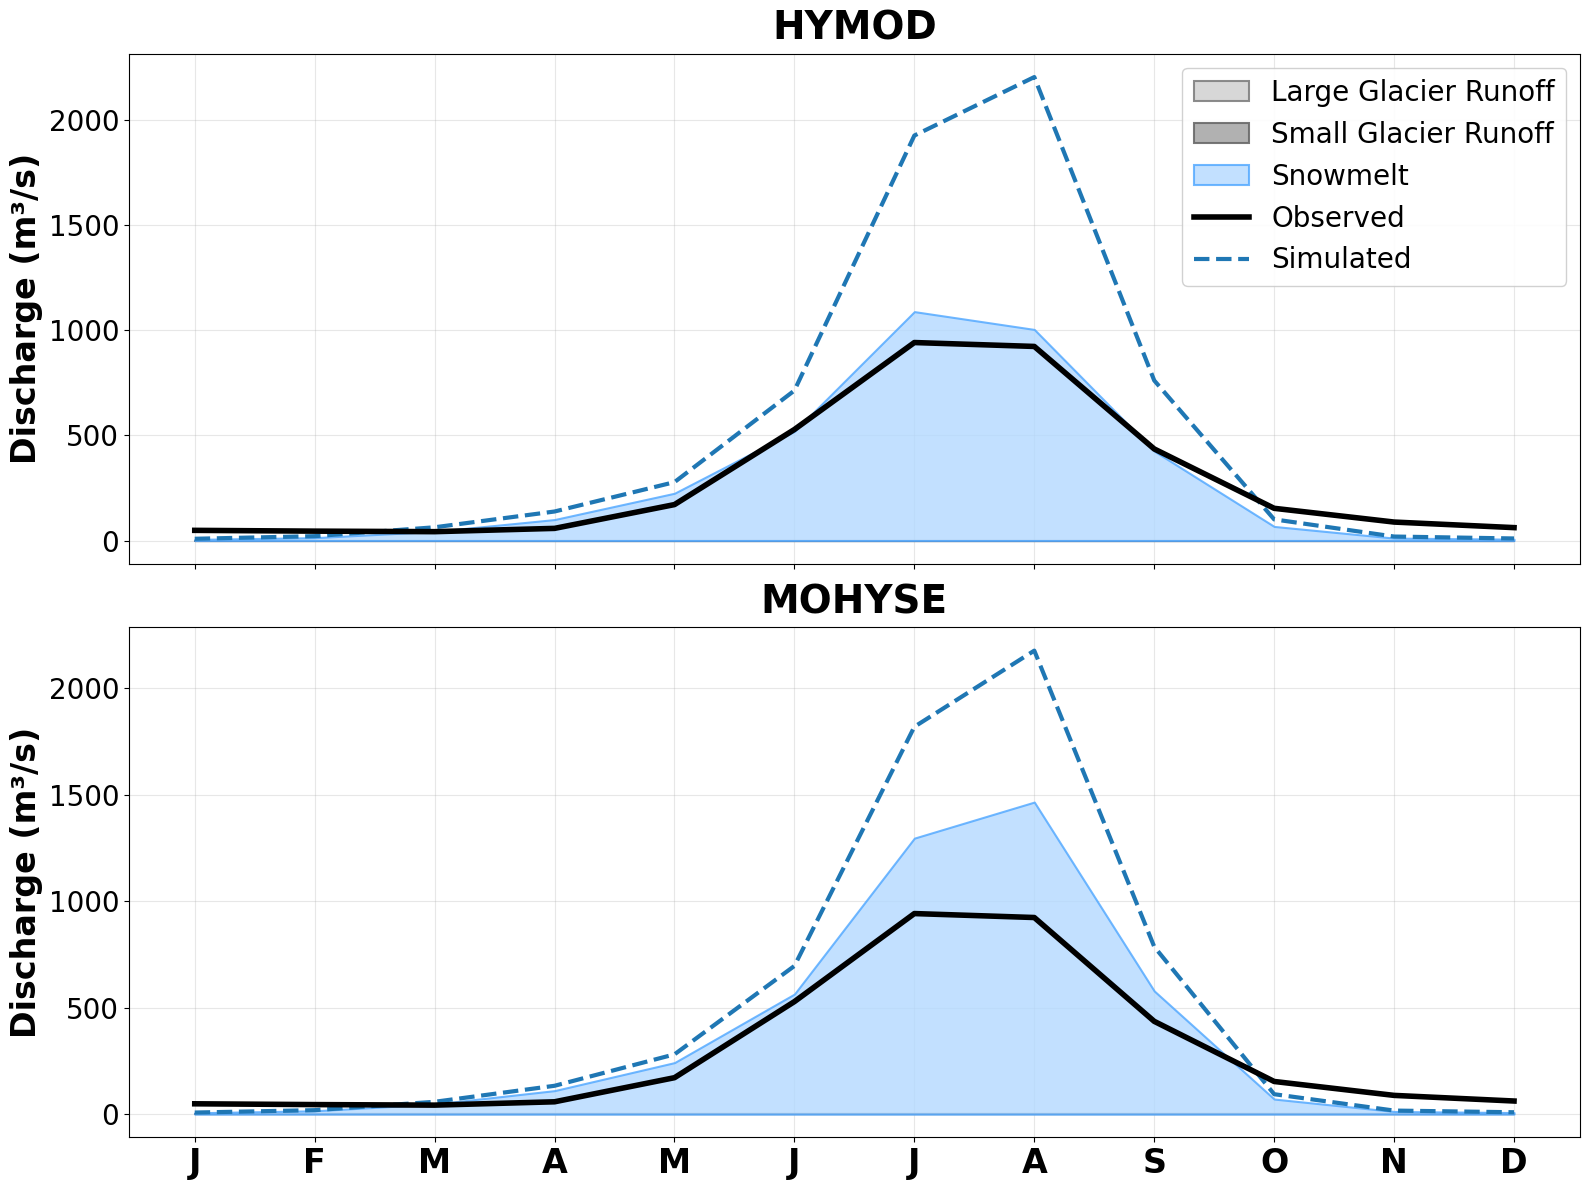


MULTI-MODEL CONTRIBUTIONS REGIME SUMMARY
Catchment: 0102
Validation period: 1995-01-01 to 2010-12-31
Successful models: 2/4
  Models loaded: HYMOD, MOHYSE

Failed models: 2
  - HBV: Snowmelt file not found
  - HMETS: Hydrograph file not found

HYMOD:
  Observed streamflow: 291.391 m³/s (mean)
  Simulated streamflow: 520.452 m³/s (mean)
  Snowmelt: 292.6066 m³/s (mean)
  Small glacier: 0.0000 m³/s (mean)
  Large glacier: 0.0000 m³/s (mean)

MOHYSE:
  Observed streamflow: 291.391 m³/s (mean)
  Simulated streamflow: 507.961 m³/s (mean)
  Snowmelt: 368.0408 m³/s (mean)
  Small glacier: 0.0000 m³/s (mean)
  Large glacier: 0.0000 m³/s (mean)


In [11]:
# Example usage
result = plot_multi_model_streamflow_with_separated_contributions(
    catchment_dir='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102',
    gauge_id='0102',
    validation_start='1995-01-01',
    validation_end='2010-12-31',
    model_types=['HBV', 'HYMOD', 'MOHYSE', 'HMETS']
)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_glogem_regime_comparison(
    geodetic_file,
    snowline_file,
    validation_start,
    validation_end,
    save_path=None
):
    """
    Compare monthly regime of 'q' from two GloGEM files for a given period.

    Parameters:
    -----------
    geodetic_file : str or Path
        Path to GloGEM_melt.csv in geodetic_mass_balance folder.
    snowline_file : str or Path
        Path to GloGEM_melt.csv in snowline folder.
    validation_start : str
        Start date (e.g., '1995-01-01').
    validation_end : str
        End date (e.g., '2010-12-31').
    save_path : str or Path, optional
        Path to save the plot (PNG). If None, plot is not saved.
    """
    # Load both files
    df_geodetic = pd.read_csv(geodetic_file, parse_dates=['date'])
    df_snowline = pd.read_csv(snowline_file, parse_dates=['date'])

    # Filter for the validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    mask_geodetic = (df_geodetic['date'] >= start_date) & (df_geodetic['date'] <= end_date)
    mask_snowline = (df_snowline['date'] >= start_date) & (df_snowline['date'] <= end_date)
    df_geodetic = df_geodetic[mask_geodetic].copy()
    df_snowline = df_snowline[mask_snowline].copy()

    # Add month column
    df_geodetic['month'] = df_geodetic['date'].dt.month
    df_snowline['month'] = df_snowline['date'].dt.month

    # Calculate monthly mean regime
    regime_geodetic = df_geodetic.groupby('month')['q'].mean()
    regime_snowline = df_snowline.groupby('month')['q'].mean()

    # Plot
    plt.figure(figsize=(12, 7))
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    plt.plot(months, regime_geodetic.reindex(months, fill_value=0), label='geodetic_mass_balance', color='#246160', linewidth=3, marker='o')
    plt.plot(months, regime_snowline.reindex(months, fill_value=0), label='snowline', color='#ef9b66', linewidth=3, marker='s', linestyle='--')

    plt.xlabel('Month', fontsize=18, fontweight='bold')
    plt.ylabel('mm/day', fontsize=18, fontweight='bold')
    plt.xticks(months, month_names, fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved plot to: {save_path}")

    plt.show()



✓ Saved plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/model_structure_plots/glogem_regime_comparison.png


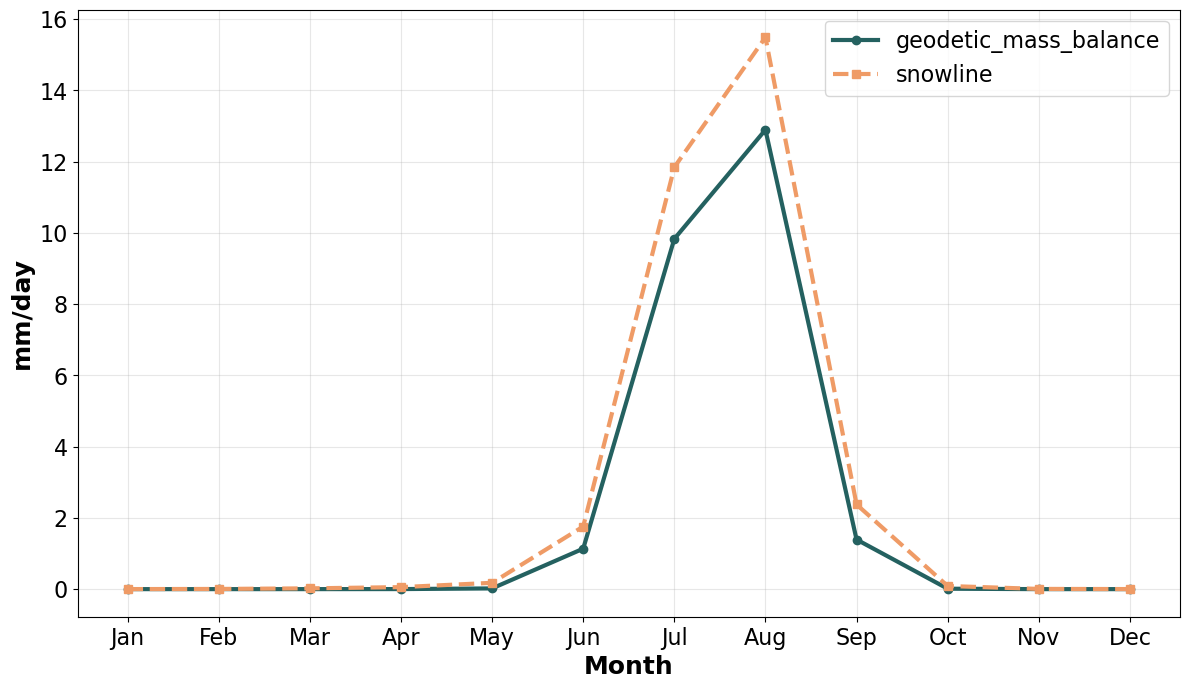

In [5]:
# Example usage:
plot_glogem_regime_comparison(
     geodetic_file='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102_geodetic/topo_files/GloGEM_melt.csv',
    snowline_file='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/GloGEM_melt.csv',
    validation_start='1995-01-01',
     validation_end='2010-12-31',
    save_path='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/model_structure_plots/glogem_regime_comparison.png'
)

In [12]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd

def plot_glogem_regime_comparison(
    geodetic_file,
    snowline_file,
    validation_start,
    validation_end,
    hydrograph_file,
    catchment_shapefile,
    save_path=None
):
    """
    Compare monthly regime of 'q' from two GloGEM files and observed streamflow for a given period.
    Scales GloGEM runoff to catchment area for direct comparison.
    """
    # Load both GloGEM files
    df_geodetic = pd.read_csv(geodetic_file, parse_dates=['date'])
    df_snowline = pd.read_csv(snowline_file, parse_dates=['date'])

    # Filter for the validation period
    start_date = pd.to_datetime(validation_start)
    end_date = pd.to_datetime(validation_end)
    mask_geodetic = (df_geodetic['date'] >= start_date) & (df_geodetic['date'] <= end_date)
    mask_snowline = (df_snowline['date'] >= start_date) & (df_snowline['date'] <= end_date)
    df_geodetic = df_geodetic[mask_geodetic].copy()
    df_snowline = df_snowline[mask_snowline].copy()

    # Add month column
    df_geodetic['month'] = df_geodetic['date'].dt.month
    df_snowline['month'] = df_snowline['date'].dt.month

    # --- Get glacier area fraction from shapefile ---
    hru_gdf = gpd.read_file(catchment_shapefile)
    # Glacier HRUs: Landuse_Cl == 8 (or 7/8, adjust as needed)
    glacier_area = hru_gdf[hru_gdf['Landuse_Cl'] == 8]['Area_km2'].sum()
    catchment_area = hru_gdf['Area_km2'].sum()
    glacier_fraction = glacier_area / catchment_area if catchment_area > 0 else 0

    # --- Scale GloGEM runoff to catchment area ---
    # (Assume 'q' is in mm/day over glacier area)
    df_geodetic['q_catchment'] = df_geodetic['q'] * glacier_fraction
    df_snowline['q_catchment'] = df_snowline['q'] * glacier_fraction

    # Calculate monthly mean regime (catchment scaled)
    regime_geodetic = df_geodetic.groupby('month')['q_catchment'].mean()
    regime_snowline = df_snowline.groupby('month')['q_catchment'].mean()

    # --- Load observed streamflow and convert to mm/day ---
    total_area_km2 = catchment_area
    conversion_factor = 86400 / (total_area_km2 * 1e6) * 1000  # m3/s to mm/day

    df_hydro = pd.read_csv(hydrograph_file, skiprows=[1])
    df_hydro['date'] = pd.to_datetime(df_hydro['date'])
    obs_col = [col for col in df_hydro.columns if '[m3/s]' in col and 'observed' in col.lower()]
    if obs_col:
        df_hydro['obs_Q'] = df_hydro[obs_col[0]]
    else:
        raise ValueError("Observed streamflow column not found in hydrograph file.")

    mask_hydro = (df_hydro['date'] >= start_date) & (df_hydro['date'] <= end_date)
    df_hydro = df_hydro[mask_hydro].copy()
    df_hydro['obs_mm_day'] = df_hydro['obs_Q'] * conversion_factor
    df_hydro['month'] = df_hydro['date'].dt.month
    regime_obs = df_hydro.groupby('month')['obs_mm_day'].mean()

    # --- Plot ---
    plt.figure(figsize=(12, 7))
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    plt.plot(months, regime_geodetic.reindex(months, fill_value=0), label='GloGEM geodetic', color='#246160', linewidth=3, marker='o')
    plt.plot(months, regime_snowline.reindex(months, fill_value=0), label='GloGEM snowline', color='#ef9b66', linewidth=3, marker='s', linestyle='--')
    plt.plot(months, regime_obs.reindex(months, fill_value=0), label='Observed Streamflow', color='k', linewidth=3, marker='^', linestyle='-')

    plt.xlabel('Month', fontsize=18, fontweight='bold')
    plt.ylabel('mm/day', fontsize=18, fontweight='bold')
    plt.xticks(months, month_names, fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved plot to: {save_path}")

    plt.show()
# ...existing code...

✓ Saved plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/model_structure_plots/glogem_regime_comparison.png


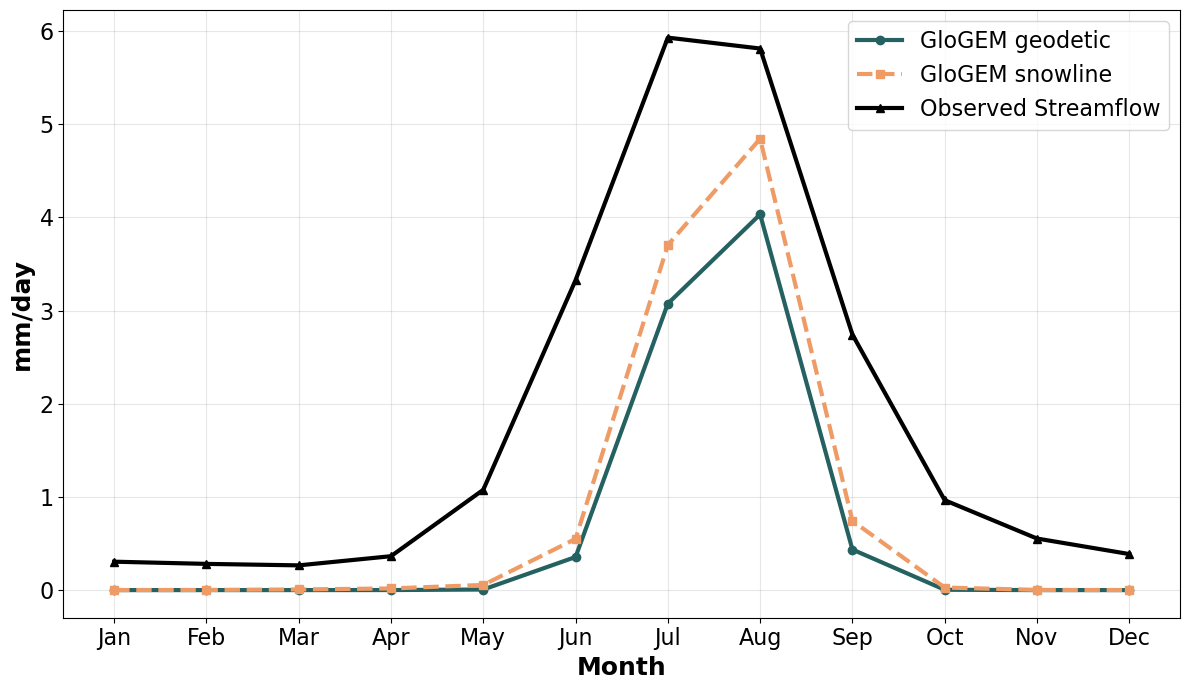

In [13]:
# Example usage:
plot_glogem_regime_comparison(
    geodetic_file='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102_geodetic/topo_files/GloGEM_melt.csv',
    snowline_file='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/GloGEM_melt.csv',
    validation_start='1995-01-01',
    validation_end='2010-12-31',
    hydrograph_file='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/0102_HBV_Hydrographs.csv',
    catchment_shapefile='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/HRU.shp',
    save_path='/home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/model_structure_plots/glogem_regime_comparison.png'
)